# SVH Patient Journey and Edema Outreach Risk Pipeline

Our Cleaned Notebook for Datafest Submission.

## 1. Setup paths and shared imports

In [2]:
from pathlib import Path
import json
import re
import warnings
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

data_dir = Path("../data")
output_dir = Path("../outputs")
table_dir = output_dir / "tables"
fig_dir = output_dir / "figures"
model_dir = output_dir / "models"

for path in [output_dir, table_dir, fig_dir, model_dir]:
    path.mkdir(parents=True, exist_ok=True)

con = duckdb.connect()

print("Data directory:", data_dir.resolve())
print("Output directory:", output_dir.resolve())


Data directory: /Users/tantrayoga/Downloads/datathon/data
Output directory: /Users/tantrayoga/Downloads/datathon/outputs


## 2. Convert raw CSV files to Parquet

In [3]:
from pathlib import Path
import duckdb

data_dir = Path("../data")
output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

source_names = [
    "encounters",
    "patients",
    "diagnosis",
    "departments",
    "providers",
    "social_determinants",
    "tigercensuscodes",
]

con = duckdb.connect()

for name in source_names:
    csv_path = data_dir / f"{name}.csv"
    parquet_path = data_dir / f"{name}.parquet"

    if parquet_path.exists():
        print(f"Already exists: {parquet_path}")
        continue

    if not csv_path.exists():
        print(f"Missing CSV, skipped: {csv_path}")
        continue

    con.sql(f"""
    COPY (
        SELECT *
        FROM read_csv_auto('{str(csv_path).replace("'", "''")}')
    )
    TO '{str(parquet_path).replace("'", "''")}'
    (FORMAT PARQUET)
    """)
    print(f"Saved: {parquet_path}")


Already exists: ../data/encounters.parquet
Already exists: ../data/patients.parquet
Already exists: ../data/diagnosis.parquet
Already exists: ../data/departments.parquet
Already exists: ../data/providers.parquet
Already exists: ../data/social_determinants.parquet
Already exists: ../data/tigercensuscodes.parquet


## 3. Build the joined master encounter table

In [4]:
from pathlib import Path

import re

import duckdb

data_dir = Path("../data")

output_dir = Path("../outputs")

output_dir.mkdir(exist_ok=True)

con = duckdb.connect()

                               

         

                               

def q(col):

    """Quote SQL identifier safely."""

    return '"' + col.replace('"', '""') + '"'

def sql_path(path):

    """Escape file path for SQL string."""

    return str(path).replace("'", "''")

def sql_lit(value):

    """Escape SQL string literal."""

    return "'" + str(value).replace("'", "''") + "'"

def clean_name(value):

    """Make safe column names from domain labels."""

    value = str(value).lower()

    value = re.sub(r"[^a-z0-9]+", "_", value)

    value = value.strip("_")

    return value[:60]

def get_cols(path):

    df = con.execute(f"""
        DESCRIBE SELECT * FROM read_parquet('{sql_path(path)}')
    """).fetchdf()

    return df["column_name"].tolist()

def prefixed_select(alias, cols, prefix):

    return [

        f'{alias}.{q(c)} AS {q(prefix + "_" + c)}'

        for c in cols

    ]

def create_dedup_view(view_name, path, key_col):

    cols = get_cols(path)

    if key_col not in cols:

        raise ValueError(f"{key_col} not found in {path.name}. Columns are: {cols}")

    col_list = ", ".join(q(c) for c in cols)

    con.execute(f"""
        CREATE OR REPLACE TEMP VIEW {view_name} AS
        SELECT {col_list}
        FROM (
            SELECT
                *,
                ROW_NUMBER() OVER (
                    PARTITION BY {q(key_col)}
                    ORDER BY {q(key_col)}
                ) AS __rn
            FROM read_parquet('{sql_path(path)}')
        )
        WHERE __rn = 1
    """)

def duplicate_report(file_name, key_col):

    path = data_dir / f"{file_name}.parquet"

    print(f"\nKey check: {file_name}.{key_col}")

    con.sql(f"""
        SELECT
            COUNT(*) AS rows,
            COUNT(DISTINCT {q(key_col)}) AS distinct_keys,
            COUNT(*) - COUNT(DISTINCT {q(key_col)}) AS duplicate_extra_rows
        FROM read_parquet('{sql_path(path)}')
    """).show()

                               

       

                               

enc_path = data_dir / "encounters.parquet"

pat_path = data_dir / "patients.parquet"

diag_path = data_dir / "diagnosis.parquet"

dep_path = data_dir / "departments.parquet"

prov_path = data_dir / "providers.parquet"

sd_path = data_dir / "social_determinants.parquet"

tiger_path = data_dir / "tigercensuscodes.parquet"

for path in [enc_path, pat_path, diag_path, dep_path, prov_path, sd_path, tiger_path]:

    if not path.exists():

        raise FileNotFoundError(f"Missing file: {path}")

                               

                    

                               

duplicate_report("encounters", "EncounterKey")

duplicate_report("patients", "DurableKey")

duplicate_report("diagnosis", "DiagnosisKey")

duplicate_report("departments", "DepartmentKey")

duplicate_report("providers", "DurableKey")

                               

                         

                               

con.execute(f"""
    CREATE OR REPLACE TEMP VIEW enc AS
    SELECT *
    FROM read_parquet('{sql_path(enc_path)}')
""")

create_dedup_view("pat", pat_path, "DurableKey")

create_dedup_view("diag", diag_path, "DiagnosisKey")

create_dedup_view("dep", dep_path, "DepartmentKey")

create_dedup_view("prov", prov_path, "DurableKey")

                               

                               

                               

tiger_cols = get_cols(tiger_path)

possible_tiger_keys = [

    "CensusBlockGroupFipsCode",

    "GEOID",

    "GEOID20",

    "FIPS",

    "Fips",

    "fips"

]

tiger_key = None

for candidate in possible_tiger_keys:

    if candidate in tiger_cols:

        tiger_key = candidate

        break

if tiger_key is None:

    for c in tiger_cols:

        if "fips" in c.lower() or "geoid" in c.lower():

            tiger_key = c

            break

use_tiger = tiger_key is not None

if use_tiger:

    print(f"\nUsing tiger census key column: {tiger_key}")

    create_dedup_view("tig", tiger_path, tiger_key)

else:

    print("\nCould not detect tiger census FIPS/GEOID key. Skipping tigercensuscodes join.")

                               

                                                  

                               

sd_cols = get_cols(sd_path)

if "EncounterKey" not in sd_cols:

    raise ValueError(

        "social_determinants.parquet does not contain EncounterKey. "

        f"Columns found: {sd_cols}"

    )

domain_col = None

for c in sd_cols:

    if "domain" in c.lower():

        domain_col = c

        break

answer_col = None

for c in sd_cols:

    lower = c.lower()

    if "answer" in lower or "response" in lower or "value" in lower:

        answer_col = c

        break

print("\nDetected social determinant columns:")

print("domain_col:", domain_col)

print("answer_col:", answer_col)

sd_agg_exprs = [

    f'{q("EncounterKey")} AS {q("EncounterKey")}',

    "COUNT(*) AS sd_num_question_rows"

]

if domain_col is not None:

    sd_agg_exprs.append(f'COUNT(DISTINCT {q(domain_col)}) AS sd_num_domains_screened')

    domains = con.execute(f"""
        SELECT DISTINCT {q(domain_col)} AS domain
        FROM read_parquet('{sql_path(sd_path)}')
        WHERE {q(domain_col)} IS NOT NULL
        ORDER BY 1
    """).fetchdf()["domain"].dropna().tolist()

    print("\nSocial determinant domains found:")

    for d in domains:

        print("-", d)

    for d in domains:

        colname = "sd_screened_" + clean_name(d)

        sd_agg_exprs.append(

            f"MAX(CASE WHEN {q(domain_col)} = {sql_lit(d)} THEN 1 ELSE 0 END) AS {q(colname)}"

        )

if answer_col is not None:

    sd_agg_exprs.append(f'COUNT({q(answer_col)}) AS sd_num_nonmissing_answers')

sd_agg_sql = ",\n            ".join(sd_agg_exprs)

con.execute(f"""
    CREATE OR REPLACE TEMP VIEW sd_agg AS
    SELECT
        {sd_agg_sql}
    FROM read_parquet('{sql_path(sd_path)}')
    GROUP BY {q("EncounterKey")}
""")

                               

                                    

                               

enc_cols = get_cols(enc_path)

pat_cols = get_cols(pat_path)

diag_cols = get_cols(diag_path)

dep_cols = get_cols(dep_path)

prov_cols = get_cols(prov_path)

select_parts = []

select_parts += prefixed_select("e", enc_cols, "enc")

select_parts += prefixed_select("p", pat_cols, "pat")

select_parts += prefixed_select("d", diag_cols, "diag")

select_parts += prefixed_select("dp", dep_cols, "dept")

select_parts += prefixed_select("ap", prov_cols, "attending_provider")

select_parts += prefixed_select("dis", prov_cols, "discharge_provider")

if use_tiger:

    select_parts += prefixed_select("t", tiger_cols, "tiger")

sd_agg_cols = con.execute("""
    DESCRIBE SELECT * FROM sd_agg
""").fetchdf()["column_name"].tolist()

for c in sd_agg_cols:

    if c == "EncounterKey":

        select_parts.append(f'sd.{q(c)} AS {q("sd_EncounterKey")}')

    else:

        select_parts.append(f'sd.{q(c)} AS {q(c)}')

select_sql = ",\n        ".join(select_parts)

join_tiger_sql = ""

if use_tiger:

    join_tiger_sql = f"""
    LEFT JOIN tig t
        ON CAST(p.{q("CensusBlockGroupFipsCode")} AS VARCHAR)
         = CAST(t.{q(tiger_key)} AS VARCHAR)
    """

master_path = output_dir / "master_encounters.parquet"

print("\nCreating master_encounters.parquet...")

con.execute(f"""
    COPY (
        SELECT
            {select_sql}
        FROM enc e
        LEFT JOIN pat p
            ON e.{q("PatientDurableKey")} = p.{q("DurableKey")}
        LEFT JOIN diag d
            ON e.{q("PrimaryDiagnosisKey")} = d.{q("DiagnosisKey")}
        LEFT JOIN dep dp
            ON e.{q("DepartmentKey")} = dp.{q("DepartmentKey")}
        LEFT JOIN prov ap
            ON e.{q("AttendingProviderDurableKey")} = ap.{q("DurableKey")}
        LEFT JOIN prov dis
            ON e.{q("DischargeProviderDurableKey")} = dis.{q("DurableKey")}
        LEFT JOIN sd_agg sd
            ON e.{q("EncounterKey")} = sd.{q("EncounterKey")}
        {join_tiger_sql}
    )
    TO '{sql_path(master_path)}'
    (FORMAT PARQUET)
""")

print("Saved:", master_path)

                               

                   

                               

print("\nValidation: original encounters row count")

con.sql(f"""
    SELECT COUNT(*) AS original_encounter_rows
    FROM read_parquet('{sql_path(enc_path)}')
""").show()

print("\nValidation: master row count")

con.sql(f"""
    SELECT
        COUNT(*) AS master_rows,
        COUNT(DISTINCT enc_EncounterKey) AS distinct_encounter_keys
    FROM read_parquet('{sql_path(master_path)}')
""").show()

print("\nValidation: match quality")

con.sql(f"""
    SELECT
        SUM(CASE WHEN pat_DurableKey IS NULL THEN 1 ELSE 0 END) AS encounters_without_patient_match,

        SUM(
            CASE
                WHEN CAST(enc_PrimaryDiagnosisKey AS VARCHAR) <> '-1'
                 AND diag_DiagnosisKey IS NULL
                THEN 1 ELSE 0
            END
        ) AS encounters_without_diagnosis_match,

        SUM(CASE WHEN dept_DepartmentKey IS NULL THEN 1 ELSE 0 END) AS encounters_without_department_match,

        SUM(CASE WHEN sd_EncounterKey IS NOT NULL THEN 1 ELSE 0 END) AS encounters_with_social_determinants
    FROM read_parquet('{sql_path(master_path)}')
""").show()

print("\nPreview:")

con.sql(f"""
    SELECT *
    FROM read_parquet('{sql_path(master_path)}')
    LIMIT 5
""").show()



Key check: encounters.EncounterKey
┌─────────┬───────────────┬──────────────────────┐
│  rows   │ distinct_keys │ duplicate_extra_rows │
│  int64  │     int64     │        int64         │
├─────────┼───────────────┼──────────────────────┤
│ 7675801 │       7675801 │                    0 │
└─────────┴───────────────┴──────────────────────┘


Key check: patients.DurableKey
┌────────┬───────────────┬──────────────────────┐
│  rows  │ distinct_keys │ duplicate_extra_rows │
│ int64  │     int64     │        int64         │
├────────┼───────────────┼──────────────────────┤
│ 947685 │        947685 │                    0 │
└────────┴───────────────┴──────────────────────┘


Key check: diagnosis.DiagnosisKey
┌─────────┬───────────────┬──────────────────────┐
│  rows   │ distinct_keys │ duplicate_extra_rows │
│  int64  │     int64     │        int64         │
├─────────┼───────────────┼──────────────────────┤
│ 1531262 │       1382555 │               148707 │
└─────────┴───────────────┴───────

## 4. Build patient journey friction tables

In [5]:
from pathlib import Path

import duckdb

                           

       

                           

data_dir = Path("../data")

output_dir = Path("../outputs")

output_dir.mkdir(exist_ok=True)

master_path = output_dir / "master_encounters.parquet"

matched_master_path = output_dir / "master_encounters_patient_matched.parquet"

journey_path = output_dir / "patient_journeys_with_friction.parquet"

if not master_path.exists():

    raise FileNotFoundError(f"Missing file: {master_path}")

con = duckdb.connect()

                           

                     

                           

print("Checking master file quality...")

con.sql(f"""
SELECT
    COUNT(*) AS master_rows,
    COUNT(DISTINCT enc_EncounterKey) AS distinct_encounter_keys,
    SUM(CASE WHEN pat_DurableKey IS NULL THEN 1 ELSE 0 END) AS no_patient_match,
    SUM(CASE WHEN diag_DiagnosisKey IS NULL AND enc_PrimaryDiagnosisKey != -1 THEN 1 ELSE 0 END) AS no_diagnosis_match,
    SUM(CASE WHEN dept_DepartmentKey IS NULL THEN 1 ELSE 0 END) AS no_department_match,
    SUM(CASE WHEN sd_EncounterKey IS NOT NULL THEN 1 ELSE 0 END) AS encounters_with_social_determinants
FROM '{master_path}'
""").show()

                           

                                       

                           

print("\nCreating patient-matched master file...")

con.sql(f"""
COPY (
    SELECT *
    FROM '{master_path}'
    WHERE pat_DurableKey IS NOT NULL
)
TO '{matched_master_path}'
(FORMAT PARQUET)
""")

print(f"Saved: {matched_master_path}")

                           

                                 

                                                    

                           

print("\nCreating patient journey table with friction score...")

con.sql(f"""
COPY (
    WITH base AS (
        SELECT
            enc_PatientDurableKey,
            diag_DiagnosisValue,
            ANY_VALUE(diag_DiagnosisName) AS DiagnosisName,
            ANY_VALUE(diag_GroupCode) AS GroupCode,
            ANY_VALUE(diag_GroupName) AS GroupName,

            ANY_VALUE(pat_PatientBirthYearBin) AS PatientBirthYearBin,
            ANY_VALUE(pat_SmokingStatus) AS SmokingStatus,
            ANY_VALUE(pat_FirstRace) AS FirstRace,
            ANY_VALUE(pat_OmbEthnicity) AS OmbEthnicity,
            ANY_VALUE(pat_OmbRace) AS OmbRace,
            ANY_VALUE(pat_MyChartStatus) AS MyChartStatus,
            ANY_VALUE(pat_CensusBlockGroupFipsCode) AS CensusBlockGroupFipsCode,

            COUNT(*) AS num_encounters,
            COUNT(DISTINCT enc_EncounterKey) AS num_unique_encounters,
            COUNT(DISTINCT enc_DepartmentKey) AS num_departments,
            COUNT(DISTINCT dept_DepartmentType) AS num_department_types,
            COUNT(DISTINCT dept_DepartmentSpecialty) AS num_department_specialties,
            COUNT(DISTINCT attending_provider_DurableKey) AS num_attending_providers,

            MIN(CAST(enc_Date AS DATE)) AS first_encounter_date,
            MAX(CAST(enc_Date AS DATE)) AS last_encounter_date,

            DATE_DIFF(
                'day',
                MIN(CAST(enc_Date AS DATE)),
                MAX(CAST(enc_Date AS DATE))
            ) AS journey_days,

            SUM(CASE WHEN enc_Type ILIKE '%hospital%' THEN 1 ELSE 0 END) AS hospital_encounters,
            SUM(CASE WHEN enc_Type ILIKE '%surgery%' THEN 1 ELSE 0 END) AS surgery_encounters,

            SUM(CASE WHEN sd_EncounterKey IS NOT NULL THEN 1 ELSE 0 END) AS encounters_with_sd_screening,
            MAX(COALESCE(sd_num_domains_screened, 0)) AS max_sd_domains_screened,
            AVG(COALESCE(sd_num_domains_screened, 0)) AS avg_sd_domains_screened

        FROM '{matched_master_path}'
        WHERE diag_DiagnosisValue IS NOT NULL
          AND enc_PrimaryDiagnosisKey != -1

        GROUP BY
            enc_PatientDurableKey,
            diag_DiagnosisValue
    ),

    scored AS (
        SELECT
            *,
            CASE
                WHEN num_encounters >= 10 THEN 1 ELSE 0
            END AS high_repeat_encounter_flag,

            CASE
                WHEN journey_days >= 90 THEN 1 ELSE 0
            END AS long_journey_flag,

            CASE
                WHEN num_departments >= 3 THEN 1 ELSE 0
            END AS multi_department_flag,

            (
                num_encounters
                + 2 * num_departments
                + 3 * num_department_types
                + 0.05 * journey_days
                + 5 * hospital_encounters
                + 5 * surgery_encounters
            ) AS friction_score

        FROM base
    )

    SELECT *
    FROM scored
)
TO '{journey_path}'
(FORMAT PARQUET)
""")

print(f"Saved: {journey_path}")

                           

                   

                           

print("\nJourney table size:")

con.sql(f"""
SELECT COUNT(*) AS num_patient_journeys
FROM '{journey_path}'
""").show()

print("\nTop high-friction journeys:")

con.sql(f"""
SELECT
    enc_PatientDurableKey,
    GroupName,
    DiagnosisName,
    num_encounters,
    num_departments,
    num_department_types,
    journey_days,
    hospital_encounters,
    surgery_encounters,
    encounters_with_sd_screening,
    MyChartStatus,
    friction_score
FROM '{journey_path}'
ORDER BY friction_score DESC
LIMIT 20
""").show()

print("\nHighest average friction by diagnosis group:")

con.sql(f"""
SELECT
    GroupName,
    COUNT(*) AS num_journeys,
    AVG(friction_score) AS avg_friction_score,
    MEDIAN(friction_score) AS median_friction_score,
    AVG(num_encounters) AS avg_encounters,
    AVG(journey_days) AS avg_journey_days
FROM '{journey_path}'
WHERE GroupName IS NOT NULL
GROUP BY GroupName
HAVING COUNT(*) >= 100
ORDER BY avg_friction_score DESC
LIMIT 20
""").show()


Checking master file quality...
┌─────────────┬─────────────────────────┬──────────────────┬────────────────────┬─────────────────────┬─────────────────────────────────────┐
│ master_rows │ distinct_encounter_keys │ no_patient_match │ no_diagnosis_match │ no_department_match │ encounters_with_social_determinants │
│    int64    │          int64          │      int128      │       int128       │       int128        │               int128                │
├─────────────┼─────────────────────────┼──────────────────┼────────────────────┼─────────────────────┼─────────────────────────────────────┤
│     7675801 │                 7675801 │           322180 │                  0 │                   0 │                               83359 │
└─────────────┴─────────────────────────┴──────────────────┴────────────────────┴─────────────────────┴─────────────────────────────────────┘


Creating patient-matched master file...
Saved: ../outputs/master_encounters_patient_matched.parquet

Creating pati

## 5. Normalize friction within diagnosis groups

In [6]:
from pathlib import Path

import duckdb

                           

       

                           

output_dir = Path("../outputs")

journey_path = output_dir / "patient_journeys_with_friction.parquet"

normalized_path = output_dir / "patient_journeys_friction_normalized.parquet"

if not journey_path.exists():

    raise FileNotFoundError(f"Missing file: {journey_path}")

con = duckdb.connect()

                           

                                            

                           

print("Creating diagnosis-normalized friction table...")

con.sql(f"""
COPY (
    WITH group_counts AS (
        SELECT
            GroupName,
            COUNT(*) AS group_journey_count
        FROM '{journey_path}'
        WHERE GroupName IS NOT NULL
        GROUP BY GroupName
    ),

    filtered AS (
        SELECT
            j.*,
            g.group_journey_count
        FROM '{journey_path}' j
        JOIN group_counts g
            ON j.GroupName = g.GroupName
        WHERE g.group_journey_count >= 100
    ),

    ranked AS (
        SELECT
            *,
            CUME_DIST() OVER (
                PARTITION BY GroupName
                ORDER BY friction_score
            ) AS friction_percentile_within_group,

            NTILE(5) OVER (
                PARTITION BY GroupName
                ORDER BY friction_score
            ) AS friction_quintile_within_group

        FROM filtered
    )

    SELECT
        *,
        CASE
            WHEN friction_percentile_within_group >= 0.80 THEN 1
            ELSE 0
        END AS high_friction_within_group,

        CASE
            WHEN friction_percentile_within_group >= 0.95 THEN 1
            ELSE 0
        END AS extreme_friction_within_group

    FROM ranked
)
TO '{normalized_path}'
(FORMAT PARQUET)
""")

print(f"Saved: {normalized_path}")

                           

                                   

                           

print("\nTop high-friction journeys after diagnosis normalization:")

con.sql(f"""
SELECT
    enc_PatientDurableKey,
    GroupName,
    DiagnosisName,
    num_encounters,
    num_departments,
    num_department_types,
    journey_days,
    hospital_encounters,
    surgery_encounters,
    encounters_with_sd_screening,
    MyChartStatus,
    friction_score,
    ROUND(friction_percentile_within_group, 3) AS friction_percentile_within_group
FROM '{normalized_path}'
WHERE extreme_friction_within_group = 1
ORDER BY friction_percentile_within_group DESC, friction_score DESC
LIMIT 25
""").show()

                           

                                      

                           

print("\nMyChart status vs diagnosis-normalized high friction:")

con.sql(f"""
SELECT
    COALESCE(MyChartStatus, 'Missing') AS MyChartStatus,
    COUNT(*) AS num_journeys,
    ROUND(AVG(high_friction_within_group) * 100, 2) AS pct_high_friction,
    ROUND(AVG(extreme_friction_within_group) * 100, 2) AS pct_extreme_friction,
    ROUND(AVG(friction_score), 2) AS avg_raw_friction
FROM '{normalized_path}'
GROUP BY COALESCE(MyChartStatus, 'Missing')
HAVING COUNT(*) >= 100
ORDER BY pct_high_friction DESC
""").show()

                           

                                                  

                           

print("\nSocial determinant screening vs diagnosis-normalized high friction:")

con.sql(f"""
SELECT
    CASE
        WHEN encounters_with_sd_screening > 0 THEN 'Screened at least once'
        ELSE 'Never screened in journey'
    END AS sd_screening_status,
    COUNT(*) AS num_journeys,
    ROUND(AVG(high_friction_within_group) * 100, 2) AS pct_high_friction,
    ROUND(AVG(extreme_friction_within_group) * 100, 2) AS pct_extreme_friction,
    ROUND(AVG(num_encounters), 2) AS avg_encounters,
    ROUND(AVG(journey_days), 2) AS avg_journey_days
FROM '{normalized_path}'
GROUP BY sd_screening_status
ORDER BY pct_high_friction DESC
""").show()

                           

                                                                

                                                                            

                                                                                   

                           

print("\nDiagnosis groups with the largest number of extreme-friction journeys:")

con.sql(f"""
SELECT
    GroupName,
    COUNT(*) AS total_journeys,
    SUM(extreme_friction_within_group) AS extreme_friction_journeys,
    ROUND(AVG(friction_score), 2) AS avg_raw_friction,
    ROUND(MEDIAN(friction_score), 2) AS median_raw_friction,
    ROUND(AVG(num_encounters), 2) AS avg_encounters,
    ROUND(AVG(journey_days), 2) AS avg_journey_days
FROM '{normalized_path}'
GROUP BY GroupName
HAVING COUNT(*) >= 100
ORDER BY extreme_friction_journeys DESC
LIMIT 20
""").show()

                           

                                               

                           

print("\nPotential screening gap: high-friction journeys with no social determinant screening:")

con.sql(f"""
SELECT
    GroupName,
    COUNT(*) AS high_friction_journeys,
    SUM(CASE WHEN encounters_with_sd_screening = 0 THEN 1 ELSE 0 END) AS high_friction_never_screened,
    ROUND(
        SUM(CASE WHEN encounters_with_sd_screening = 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS pct_high_friction_never_screened
FROM '{normalized_path}'
WHERE high_friction_within_group = 1
GROUP BY GroupName
HAVING COUNT(*) >= 100
ORDER BY pct_high_friction_never_screened DESC
LIMIT 20
""").show()

print("\nDone.")


Creating diagnosis-normalized friction table...
Saved: ../outputs/patient_journeys_friction_normalized.parquet

Top high-friction journeys after diagnosis normalization:
┌───────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────┬─────────────────┬──────────────────────┬──────────────┬─────────────────────┬────────────────────┬──────────────────────────────┬────────────────────┬────────────────┬──────────────────────────────────┐
│ enc_PatientDurableKey │                                          GroupName                                           │                                                   DiagnosisName                                                    │ num_encounters │ num_departments │ num_department_types │ journey_days │ hospital_encounters │ surgery_encounters │ encounters_with_sd

## 6. Export friction, screening, and journey dashboard resources


1. OVERALL DATA SUMMARY


,total_journeys,unique_patients,diagnosis_groups,avg_friction_score,median_friction_score,avg_encounters_per_journey,avg_journey_days,pct_high_friction,pct_extreme_friction
0,2615694,338458,872,16.81,9.0,2.24,140.16,30.4,6.3



2. MYCHART STATUS VS HIGH FRICTION


,MyChartStatus,num_journeys,pct_high_friction,pct_extreme_friction,avg_encounters,avg_journey_days,avg_raw_friction
0,Non Standard MyChart Status,19793,34.04,6.86,1.46,85.35,12.46
1,Activated,2187388,30.77,6.49,2.29,147.10,17.22
2,Patient Declined,19352,30.49,6.72,2.43,158.68,18.60
3,*Unspecified,14647,30.03,6.60,1.24,26.12,9.31
4,Pending Activation,288464,28.38,5.11,1.96,108.06,14.94
5,Inactivated,85916,27.17,5.03,2.09,99.33,14.55
6,"Activation Code Generated, but Disabled",134,18.66,2.99,1.36,63.52,10.91


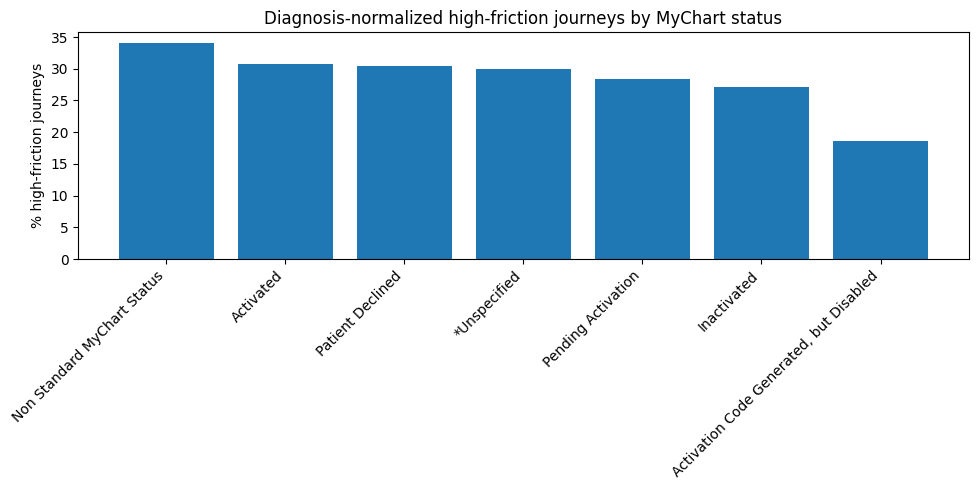


3. SOCIAL DETERMINANT SCREENING VS HIGH FRICTION


,sd_screening_status,num_journeys,pct_high_friction,pct_extreme_friction,avg_encounters,avg_journey_days,avg_raw_friction
0,Screened at least once,73825,43.65,11.23,3.46,350.82,30.50
1,Never screened in journey,2541869,30.02,6.16,2.20,134.04,16.41


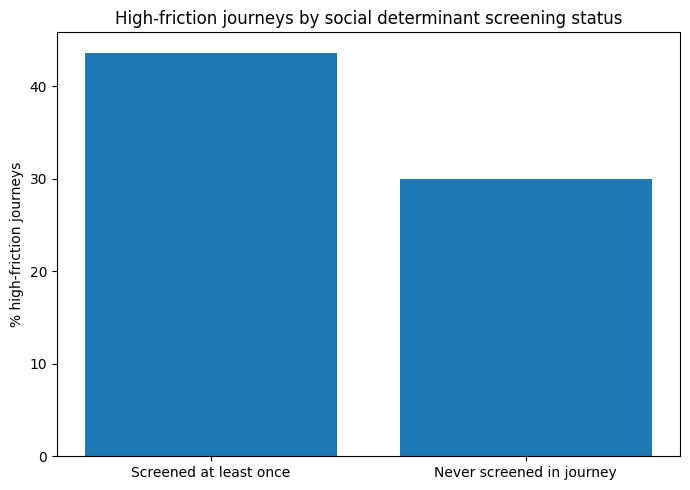


4. SCREENING GAP AMONG HIGH-FRICTION JOURNEYS


,GroupName,high_friction_journeys,high_friction_never_screened,pct_high_friction_never_screened,avg_encounters,avg_journey_days,avg_friction_score
0,Persons encountering health services for speci...,5909,5909.0,100.0,1.24,57.57,15.28
1,Influenza due to unidentified influenza virus,2360,2360.0,100.0,1.14,7.19,7.08
2,zzdonotuse errenc,2290,2290.0,100.0,1.35,38.54,14.51
3,Other disorders of pigmentation,1979,1979.0,100.0,1.24,60.82,9.49
4,Other viral infections characterized by skin a...,1959,1959.0,100.0,1.10,16.19,7.36
5,Impetigo,1900,1900.0,100.0,1.13,20.59,7.51
6,Nonsuppurative otitis media,1854,1854.0,100.0,1.15,40.81,13.28
7,Skin changes due to chronic exposure to nonion...,1365,1365.0,100.0,3.24,832.62,49.95
8,Conductive and sensorineural hearing loss,1295,1295.0,100.0,3.02,119.60,15.70
9,Other and unspecified disorders of eustachian ...,1270,1270.0,100.0,1.70,126.56,17.16


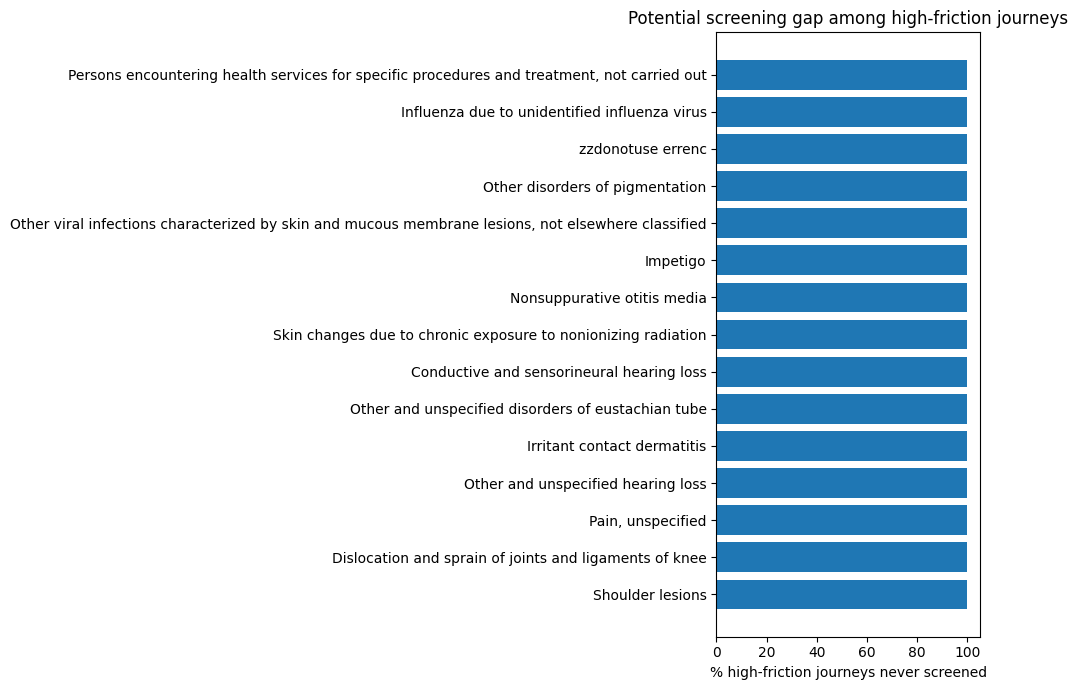


5. DIAGNOSIS GROUPS WITH MANY EXTREME-FRICTION JOURNEYS


,GroupName,total_journeys,extreme_friction_journeys,pct_extreme_friction,avg_encounters,avg_journey_days,avg_friction_score
0,Encounter for general examination without comp...,157351,7918.0,5.03,3.15,522.35,35.45
1,Liveborn infants according to place of birth a...,6976,6929.0,99.33,1.02,0.42,11.18
2,Other diseases of intestine,9219,5521.0,59.89,1.08,16.39,10.15
3,"Other joint disorder, not elsewhere classified",81933,4099.0,5.00,2.90,77.20,15.31
4,Encounter for screening for malignant neoplasms,73270,3679.0,5.02,1.86,331.62,24.96
5,Open wound of head,5441,3441.0,63.24,1.07,5.96,9.69
6,Chronic diseases of tonsils and adenoids,4058,3098.0,76.34,1.08,4.18,10.21
7,Dorsalgia,60989,3056.0,5.01,2.77,106.00,19.31
8,Essential,50984,2554.0,5.01,4.04,468.70,34.84
9,Abdominal and pelvic pain,47773,2390.0,5.00,1.59,38.86,12.18



6. TOP EXTREME JOURNEYS FOR CASE EXAMPLES


,enc_PatientDurableKey,GroupName,DiagnosisName,MyChartStatus,num_encounters,num_departments,num_department_types,num_attending_providers,journey_days,hospital_encounters,surgery_encounters,encounters_with_sd_screening,max_sd_domains_screened,friction_score,friction_percentile_within_group
0,8602439,Disorders of mineral metabolism,Hypomagnesemia( ICD-10-CM: E83.42 ),Activated,288,8,4,6,1348,273.0,0.0,0.0,0,1748.40,1.0000
1,7136932,Volume depletion,Dehydration( ICD-10-CM: E86.0 ),Activated,222,2,2,7,1427,222.0,0.0,0.0,0,1413.35,1.0000
2,5511800,Volume depletion,Dehydration( ICD-10-CM: E86.0 ),Inactivated,154,2,2,3,1146,153.0,0.0,0.0,0,986.30,0.9992
3,5449851,Postprocedural endocrine and metabolic complic...,Postprocedural hypothyroidism( ICD-10-CM: E89.0 ),Activated,109,1,1,1,1417,109.0,0.0,0.0,0,729.85,1.0000
4,8359292,Malignant neoplasm of rectum,Malignant neoplasm of rectum (HCC) (Multi HCC)...,Activated,176,15,3,13,1175,91.0,0.0,0.0,0,728.75,1.0000
5,5508801,Asthma,"Severe persistent asthma, uncomplicated (Multi...",Activated,112,3,2,3,1445,103.0,0.0,0.0,0,711.25,1.0000
6,4255801,Osteomyelitis,"Chronic multifocal osteomyelitis, right ankle ...",Activated,113,1,1,3,496,113.0,0.0,0.0,0,707.80,1.0000
7,5603709,Dermatopolymyositis,"Dermatopolymyositis, unspecified with respirat...",Activated,147,9,2,2,1422,92.0,0.0,0.0,0,702.10,1.0000
8,2701367,Myasthenia gravis and other myoneural disorders,Myasthenia gravis without (acute) exacerbation...,Activated,112,4,2,4,1400,101.0,0.0,0.0,0,701.00,1.0000
9,8588151,Asthma,"Moderate persistent asthma, uncomplicated (HHS...",Activated,103,1,1,3,1454,103.0,0.0,0.0,0,695.70,0.9999



7. DEPARTMENT-TYPE SCREENING HEATMAP


,DepartmentType,alcohol_use,depression,financial_resource_strain,food_insecurity,housing_stability,na,transportation_needs,utilities,intimate_partner_violance,physical_activity,social_connections,stress
0,*Unknown,0.88,0.13,1.03,1.04,0.72,0.41,1.05,0.86,0.64,0.87,0.80,0.92
1,ED,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,HOD,0.10,0.12,0.14,0.14,0.14,0.02,0.14,0.11,0.14,0.11,0.11,0.11
3,ICU,6.37,6.03,8.61,8.58,8.56,1.36,8.56,6.56,8.60,6.58,6.62,6.50
4,L&D,0.03,7.87,10.01,10.00,10.00,0.68,10.00,0.04,9.98,0.04,0.03,0.04
5,Normal,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
6,OR,0.01,0.00,0.02,0.02,0.02,0.00,0.02,0.01,0.02,0.01,0.01,0.01
7,SNF/NF,93.33,93.33,100.00,100.00,100.00,6.67,100.00,93.33,100.00,93.33,93.33,93.33


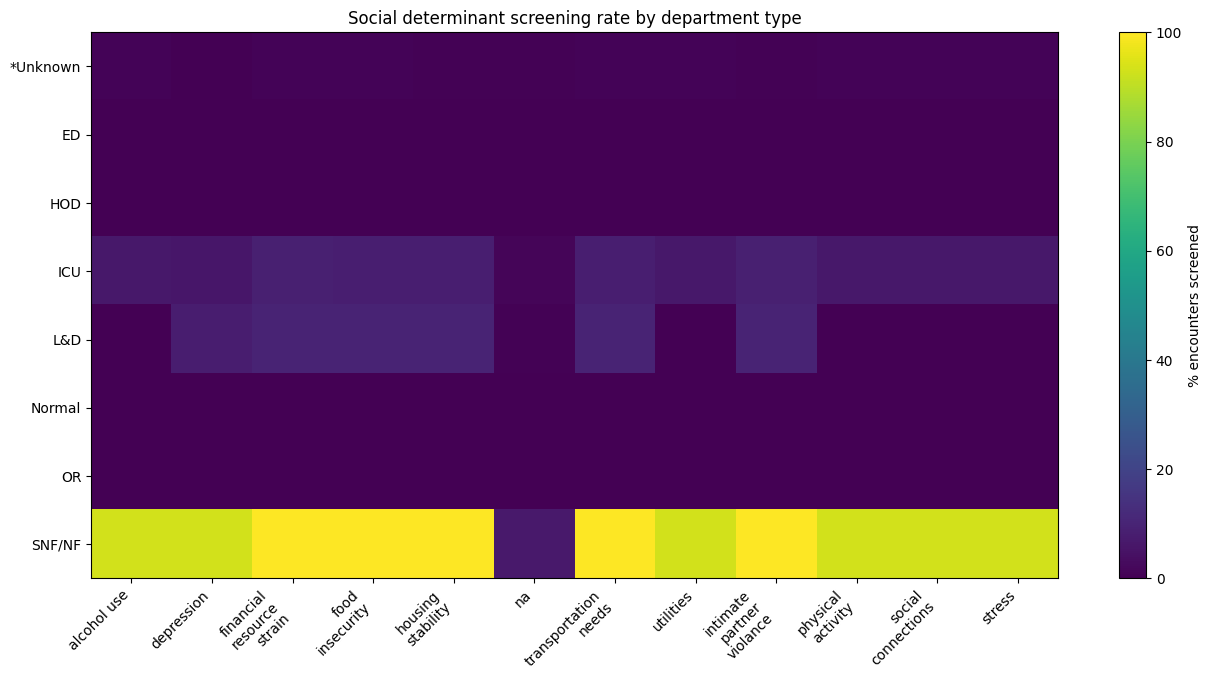


8. FRICTION SCORE DISTRIBUTION


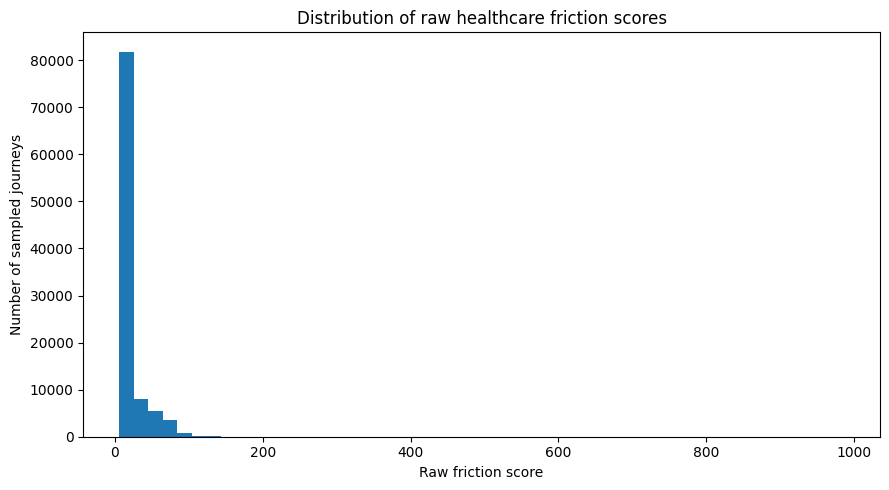


DONE — WHAT TO USE FOR YOUR PRESENTATION

You now have judge-ready outputs in:

Tables:
../outputs/tables

Figures:
../outputs/figures

Recommended story:
1. We transformed millions of encounter rows into patient journeys.
2. We measured healthcare friction using encounters, departments, providers, time span, hospital use, and surgery use.
3. We normalized friction within diagnosis groups so different diseases are not unfairly compared.
4. We identified high-friction journeys.
5. We checked whether high-friction patients were actually screened for social determinants.
6. We found potential screening gaps by diagnosis group and department type.
7. Recommendation: prioritize social determinant screening and support services for diagnosis groups/departments where high-friction journeys are common but screening is low.

Best tables to open:
- 02_mychart_vs_high_friction.csv
- 03_sd_screening_vs_high_friction.csv
- 04_screening_gap_high_friction_by_diagnosis_group.csv
- 05_extreme_friction

In [7]:
from pathlib import Path

import duckdb

import pandas as pd

import matplotlib.pyplot as plt

import numpy as np

import textwrap

                                                              

       

                                                              

output_dir = Path("../outputs")

fig_dir = output_dir / "figures"

table_dir = output_dir / "tables"

fig_dir.mkdir(parents=True, exist_ok=True)

table_dir.mkdir(parents=True, exist_ok=True)

master_path = output_dir / "master_encounters.parquet"

journey_path = output_dir / "patient_journeys_with_friction.parquet"

normalized_path = output_dir / "patient_journeys_friction_normalized.parquet"

con = duckdb.connect()

if not master_path.exists():

    raise FileNotFoundError(f"Missing {master_path}. You need master_encounters.parquet first.")

if not normalized_path.exists():

    if not journey_path.exists():

        raise FileNotFoundError(

            f"Missing {normalized_path} and {journey_path}. "

            "Create the patient journey table first."

        )

    print("Normalized journey file not found. Creating it now...")

    con.sql(f"""
    COPY (
        WITH group_counts AS (
            SELECT
                GroupName,
                COUNT(*) AS group_journey_count
            FROM '{journey_path}'
            WHERE GroupName IS NOT NULL
            GROUP BY GroupName
        ),

        filtered AS (
            SELECT
                j.*,
                g.group_journey_count
            FROM '{journey_path}' j
            JOIN group_counts g
                ON j.GroupName = g.GroupName
            WHERE g.group_journey_count >= 100
        ),

        ranked AS (
            SELECT
                *,
                CUME_DIST() OVER (
                    PARTITION BY GroupName
                    ORDER BY friction_score
                ) AS friction_percentile_within_group,

                NTILE(5) OVER (
                    PARTITION BY GroupName
                    ORDER BY friction_score
                ) AS friction_quintile_within_group
            FROM filtered
        )

        SELECT
            *,
            CASE
                WHEN friction_percentile_within_group >= 0.80 THEN 1
                ELSE 0
            END AS high_friction_within_group,

            CASE
                WHEN friction_percentile_within_group >= 0.95 THEN 1
                ELSE 0
            END AS extreme_friction_within_group
        FROM ranked
    )
    TO '{normalized_path}'
    (FORMAT PARQUET)
    """)

    print(f"Saved {normalized_path}")

                                                              

                    

                                                              

print("\n==============================")

print("1. OVERALL DATA SUMMARY")

print("==============================")

overview = con.sql(f"""
SELECT
    COUNT(*) AS total_journeys,
    COUNT(DISTINCT enc_PatientDurableKey) AS unique_patients,
    COUNT(DISTINCT GroupName) AS diagnosis_groups,
    ROUND(AVG(friction_score), 2) AS avg_friction_score,
    ROUND(MEDIAN(friction_score), 2) AS median_friction_score,
    ROUND(AVG(num_encounters), 2) AS avg_encounters_per_journey,
    ROUND(AVG(journey_days), 2) AS avg_journey_days,
    ROUND(AVG(high_friction_within_group) * 100, 2) AS pct_high_friction,
    ROUND(AVG(extreme_friction_within_group) * 100, 2) AS pct_extreme_friction
FROM '{normalized_path}'
""").fetchdf()

display(overview)

overview.to_csv(table_dir / "01_overall_summary.csv", index=False)

                                                              

                                      

                                                              

print("\n==============================")

print("2. MYCHART STATUS VS HIGH FRICTION")

print("==============================")

mychart = con.sql(f"""
SELECT
    COALESCE(MyChartStatus, 'Missing') AS MyChartStatus,
    COUNT(*) AS num_journeys,
    ROUND(AVG(high_friction_within_group) * 100, 2) AS pct_high_friction,
    ROUND(AVG(extreme_friction_within_group) * 100, 2) AS pct_extreme_friction,
    ROUND(AVG(num_encounters), 2) AS avg_encounters,
    ROUND(AVG(journey_days), 2) AS avg_journey_days,
    ROUND(AVG(friction_score), 2) AS avg_raw_friction
FROM '{normalized_path}'
GROUP BY COALESCE(MyChartStatus, 'Missing')
HAVING COUNT(*) >= 100
ORDER BY pct_high_friction DESC
""").fetchdf()

display(mychart)

mychart.to_csv(table_dir / "02_mychart_vs_high_friction.csv", index=False)

plt.figure(figsize=(10, 5))

plt.bar(mychart["MyChartStatus"].astype(str), mychart["pct_high_friction"])

plt.xticks(rotation=45, ha="right")

plt.ylabel("% high-friction journeys")

plt.title("Diagnosis-normalized high-friction journeys by MyChart status")

plt.tight_layout()

plt.savefig(fig_dir / "02_mychart_vs_high_friction.png", dpi=200)

plt.show()

                                                              

                                                  

                                                              

print("\n==============================")

print("3. SOCIAL DETERMINANT SCREENING VS HIGH FRICTION")

print("==============================")

sd_screening = con.sql(f"""
SELECT
    CASE
        WHEN encounters_with_sd_screening > 0 THEN 'Screened at least once'
        ELSE 'Never screened in journey'
    END AS sd_screening_status,
    COUNT(*) AS num_journeys,
    ROUND(AVG(high_friction_within_group) * 100, 2) AS pct_high_friction,
    ROUND(AVG(extreme_friction_within_group) * 100, 2) AS pct_extreme_friction,
    ROUND(AVG(num_encounters), 2) AS avg_encounters,
    ROUND(AVG(journey_days), 2) AS avg_journey_days,
    ROUND(AVG(friction_score), 2) AS avg_raw_friction
FROM '{normalized_path}'
GROUP BY sd_screening_status
ORDER BY pct_high_friction DESC
""").fetchdf()

display(sd_screening)

sd_screening.to_csv(table_dir / "03_sd_screening_vs_high_friction.csv", index=False)

plt.figure(figsize=(7, 5))

plt.bar(sd_screening["sd_screening_status"], sd_screening["pct_high_friction"])

plt.ylabel("% high-friction journeys")

plt.title("High-friction journeys by social determinant screening status")

plt.tight_layout()

plt.savefig(fig_dir / "03_sd_screening_vs_high_friction.png", dpi=200)

plt.show()

                                                              

                                               

                                                              

print("\n==============================")

print("4. SCREENING GAP AMONG HIGH-FRICTION JOURNEYS")

print("==============================")

screening_gap = con.sql(f"""
SELECT
    GroupName,
    COUNT(*) AS high_friction_journeys,
    SUM(CASE WHEN encounters_with_sd_screening = 0 THEN 1 ELSE 0 END) AS high_friction_never_screened,
    ROUND(
        SUM(CASE WHEN encounters_with_sd_screening = 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS pct_high_friction_never_screened,
    ROUND(AVG(num_encounters), 2) AS avg_encounters,
    ROUND(AVG(journey_days), 2) AS avg_journey_days,
    ROUND(AVG(friction_score), 2) AS avg_friction_score
FROM '{normalized_path}'
WHERE high_friction_within_group = 1
GROUP BY GroupName
HAVING COUNT(*) >= 100
ORDER BY pct_high_friction_never_screened DESC, high_friction_journeys DESC
LIMIT 25
""").fetchdf()

display(screening_gap)

screening_gap.to_csv(table_dir / "04_screening_gap_high_friction_by_diagnosis_group.csv", index=False)

top_gap = screening_gap.head(15).copy()

plt.figure(figsize=(10, 7))

plt.barh(top_gap["GroupName"].astype(str), top_gap["pct_high_friction_never_screened"])

plt.xlabel("% high-friction journeys never screened")

plt.title("Potential screening gap among high-friction journeys")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(fig_dir / "04_screening_gap_high_friction_by_diagnosis_group.png", dpi=200)

plt.show()

                                                              

                                                     

                                                              

print("\n==============================")

print("5. DIAGNOSIS GROUPS WITH MANY EXTREME-FRICTION JOURNEYS")

print("==============================")

extreme_groups = con.sql(f"""
SELECT
    GroupName,
    COUNT(*) AS total_journeys,
    SUM(extreme_friction_within_group) AS extreme_friction_journeys,
    ROUND(SUM(extreme_friction_within_group) * 100.0 / COUNT(*), 2) AS pct_extreme_friction,
    ROUND(AVG(num_encounters), 2) AS avg_encounters,
    ROUND(AVG(journey_days), 2) AS avg_journey_days,
    ROUND(AVG(friction_score), 2) AS avg_friction_score
FROM '{normalized_path}'
GROUP BY GroupName
HAVING COUNT(*) >= 100
ORDER BY extreme_friction_journeys DESC
LIMIT 25
""").fetchdf()

display(extreme_groups)

extreme_groups.to_csv(table_dir / "05_extreme_friction_diagnosis_groups.csv", index=False)

                                                              

                                                      

                                                              

print("\n==============================")

print("6. TOP EXTREME JOURNEYS FOR CASE EXAMPLES")

print("==============================")

top_journeys = con.sql(f"""
SELECT
    enc_PatientDurableKey,
    GroupName,
    DiagnosisName,
    MyChartStatus,
    num_encounters,
    num_departments,
    num_department_types,
    num_attending_providers,
    journey_days,
    hospital_encounters,
    surgery_encounters,
    encounters_with_sd_screening,
    max_sd_domains_screened,
    ROUND(friction_score, 2) AS friction_score,
    ROUND(friction_percentile_within_group, 4) AS friction_percentile_within_group
FROM '{normalized_path}'
WHERE extreme_friction_within_group = 1
ORDER BY friction_score DESC
LIMIT 50
""").fetchdf()

display(top_journeys)

top_journeys.to_csv(table_dir / "06_top_extreme_journeys.csv", index=False)

                                                              

                                                         

                                                              

print("\n==============================")

print("7. DEPARTMENT-TYPE SCREENING HEATMAP")

print("==============================")

master_cols = con.execute(f"""
DESCRIBE SELECT * FROM '{master_path}'
""").fetchdf()["column_name"].tolist()

sd_domain_cols = [

    c for c in master_cols

    if c.startswith("sd_screened_")

]

if len(sd_domain_cols) == 0:

    print("No sd_screened_* columns found in master file. Skipping heatmap.")

else:

    top_departments = con.sql(f"""
    SELECT
        COALESCE(dept_DepartmentType, 'Missing') AS DepartmentType,
        COUNT(*) AS encounters
    FROM '{master_path}'
    GROUP BY COALESCE(dept_DepartmentType, 'Missing')
    ORDER BY encounters DESC
    LIMIT 15
    """).fetchdf()

    dept_list = top_departments["DepartmentType"].tolist()

    dept_sql = ", ".join("'" + str(x).replace("'", "''") + "'" for x in dept_list)

    agg_exprs = []

    for c in sd_domain_cols:

        label = c.replace("sd_screened_", "")

        agg_exprs.append(

            f"ROUND(AVG(COALESCE({c}, 0)) * 100, 2) AS \"{label}\""

        )

    heatmap_query = f"""
    SELECT
        COALESCE(dept_DepartmentType, 'Missing') AS DepartmentType,
        {", ".join(agg_exprs)}
    FROM '{master_path}'
    WHERE COALESCE(dept_DepartmentType, 'Missing') IN ({dept_sql})
    GROUP BY COALESCE(dept_DepartmentType, 'Missing')
    ORDER BY DepartmentType
    """

    heatmap_df = con.sql(heatmap_query).fetchdf()

    display(heatmap_df)

    heatmap_df.to_csv(table_dir / "07_department_type_sd_screening_heatmap_data.csv", index=False)

    plot_df = heatmap_df.set_index("DepartmentType")

                         

    row_labels = [

        "\n".join(textwrap.wrap(str(x), width=24))

        for x in plot_df.index

    ]

    col_labels = [

        "\n".join(textwrap.wrap(str(x).replace("_", " "), width=14))

        for x in plot_df.columns

    ]

    plt.figure(figsize=(max(12, len(col_labels) * 1.1), max(7, len(row_labels) * 0.55)))

    plt.imshow(plot_df.values, aspect="auto")

    plt.colorbar(label="% encounters screened")

    plt.xticks(np.arange(len(col_labels)), col_labels, rotation=45, ha="right")

    plt.yticks(np.arange(len(row_labels)), row_labels)

    plt.title("Social determinant screening rate by department type")

    plt.tight_layout()

    plt.savefig(fig_dir / "07_department_type_sd_screening_heatmap.png", dpi=200)

    plt.show()

                                                              

                          

                                                              

print("\n==============================")

print("8. FRICTION SCORE DISTRIBUTION")

print("==============================")

friction_sample = con.sql(f"""
SELECT friction_score
FROM '{normalized_path}'
USING SAMPLE 100000 ROWS
""").fetchdf()

plt.figure(figsize=(9, 5))

plt.hist(friction_sample["friction_score"], bins=50)

plt.xlabel("Raw friction score")

plt.ylabel("Number of sampled journeys")

plt.title("Distribution of raw healthcare friction scores")

plt.tight_layout()

plt.savefig(fig_dir / "08_friction_score_distribution.png", dpi=200)

plt.show()

                                                              

                                  

                                                              

print("\n==============================")

print("DONE — WHAT TO USE FOR YOUR PRESENTATION")

print("==============================")

print(f"""
You now have judge-ready outputs in:

Tables:
{table_dir}

Figures:
{fig_dir}

Recommended story:
1. We transformed millions of encounter rows into patient journeys.
2. We measured healthcare friction using encounters, departments, providers, time span, hospital use, and surgery use.
3. We normalized friction within diagnosis groups so different diseases are not unfairly compared.
4. We identified high-friction journeys.
5. We checked whether high-friction patients were actually screened for social determinants.
6. We found potential screening gaps by diagnosis group and department type.
7. Recommendation: prioritize social determinant screening and support services for diagnosis groups/departments where high-friction journeys are common but screening is low.

Best tables to open:
- 02_mychart_vs_high_friction.csv
- 03_sd_screening_vs_high_friction.csv
- 04_screening_gap_high_friction_by_diagnosis_group.csv
- 05_extreme_friction_diagnosis_groups.csv
- 07_department_type_sd_screening_heatmap_data.csv

Best figures to use:
- 02_mychart_vs_high_friction.png
- 03_sd_screening_vs_high_friction.png
- 04_screening_gap_high_friction_by_diagnosis_group.png
- 07_department_type_sd_screening_heatmap.png
- 08_friction_score_distribution.png
""")


## 7. Add deceased flag to patient journeys

In [8]:
from pathlib import Path

import duckdb

                           

       

                           

data_dir = Path("../data")

output_dir = Path("../outputs")

patients_path = data_dir / "patients.parquet"

master_path = output_dir / "master_encounters.parquet"

journey_path = output_dir / "patient_journeys_friction_normalized.parquet"

con = duckdb.connect()

                           

                                       

                           

print("VitalStatus counts in patients.parquet:")

con.sql(f"""
SELECT
    VitalStatus,
    COUNT(*) AS num_patients,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct_patients
FROM '{patients_path}'
GROUP BY VitalStatus
ORDER BY num_patients DESC
""").show()

                           

                                               

                           

print("\nVitalStatus counts in master_encounters.parquet:")

con.sql(f"""
SELECT
    pat_VitalStatus,
    COUNT(*) AS num_encounters,
    COUNT(DISTINCT enc_PatientDurableKey) AS num_patients,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct_encounters
FROM '{master_path}'
GROUP BY pat_VitalStatus
ORDER BY num_encounters DESC
""").show()

                           

                                             

                           

                                                                                  

                                                                           

                           

journey_cols = con.sql(f"""
DESCRIBE SELECT *
FROM '{journey_path}'
""").fetchdf()["column_name"].tolist()

if "VitalStatus" in journey_cols:

    vital_col = "VitalStatus"

elif "pat_VitalStatus" in journey_cols:

    vital_col = "pat_VitalStatus"

else:

    vital_col = None

if vital_col is not None:

    print(f"\nJourney table already contains VitalStatus column: {vital_col}")

    con.sql(f"""
    COPY (
        SELECT
            *,
            CASE
                WHEN UPPER(CAST({vital_col} AS VARCHAR)) LIKE '%DECEASED%'
                  OR UPPER(CAST({vital_col} AS VARCHAR)) LIKE '%DEAD%'
                  OR UPPER(CAST({vital_col} AS VARCHAR)) LIKE '%DIED%'
                THEN 1 ELSE 0
            END AS is_deceased
        FROM '{journey_path}'
    )
    TO '{output_dir / "patient_journeys_with_deceased_flag.parquet"}'
    (FORMAT PARQUET)
    """)

else:

    print("\nJourney table does not contain VitalStatus, joining it from patients.parquet...")

    con.sql(f"""
    COPY (
        SELECT
            j.*,
            p.VitalStatus,
            CASE
                WHEN UPPER(CAST(p.VitalStatus AS VARCHAR)) LIKE '%DECEASED%'
                  OR UPPER(CAST(p.VitalStatus AS VARCHAR)) LIKE '%DEAD%'
                  OR UPPER(CAST(p.VitalStatus AS VARCHAR)) LIKE '%DIED%'
                THEN 1 ELSE 0
            END AS is_deceased
        FROM '{journey_path}' j
        LEFT JOIN '{patients_path}' p
            ON j.enc_PatientDurableKey = p.DurableKey
    )
    TO '{output_dir / "patient_journeys_with_deceased_flag.parquet"}'
    (FORMAT PARQUET)
    """)

print("\nSaved: ../outputs/patient_journeys_with_deceased_flag.parquet")

                           

                                             

                           

print("\nDeceased rate by high-friction journey status:")

con.sql(f"""
SELECT
    high_friction_within_group,
    COUNT(*) AS num_journeys,
    COUNT(DISTINCT enc_PatientDurableKey) AS num_patients,
    SUM(is_deceased) AS deceased_journeys,
    ROUND(AVG(is_deceased) * 100, 2) AS pct_deceased
FROM '{output_dir / "patient_journeys_with_deceased_flag.parquet"}'
GROUP BY high_friction_within_group
ORDER BY high_friction_within_group DESC
""").show()

print("\nDeceased rate by diagnosis group among high-friction journeys:")

con.sql(f"""
SELECT
    GroupName,
    COUNT(*) AS high_friction_journeys,
    SUM(is_deceased) AS deceased_journeys,
    ROUND(AVG(is_deceased) * 100, 2) AS pct_deceased
FROM '{output_dir / "patient_journeys_with_deceased_flag.parquet"}'
WHERE high_friction_within_group = 1
GROUP BY GroupName
HAVING COUNT(*) >= 100
ORDER BY pct_deceased DESC
LIMIT 20
""").show()


VitalStatus counts in patients.parquet:
┌─────────────┬──────────────┬──────────────┐
│ VitalStatus │ num_patients │ pct_patients │
│   varchar   │    int64     │    double    │
├─────────────┼──────────────┼──────────────┤
│ Alive       │       941570 │        99.35 │
│ Deceased    │         6115 │         0.65 │
└─────────────┴──────────────┴──────────────┘


VitalStatus counts in master_encounters.parquet:
┌─────────────────┬────────────────┬──────────────┬────────────────┐
│ pat_VitalStatus │ num_encounters │ num_patients │ pct_encounters │
│     varchar     │     int64      │    int64     │     double     │
├─────────────────┼────────────────┼──────────────┼────────────────┤
│ Alive           │        7091672 │       344948 │          92.39 │
│ NULL            │         322180 │        10320 │            4.2 │
│ Deceased        │         261949 │         4492 │           3.41 │
└─────────────────┴────────────────┴──────────────┴────────────────┘


Journey table does not contain Vi

## 8. Build the edema landmark early-window feature table

In [9]:
from pathlib import Path
import duckdb

output_dir = Path("../outputs")
table_dir = output_dir / "tables"
fig_dir = output_dir / "figures"
model_dir = output_dir / "models"

for path in [output_dir, table_dir, fig_dir, model_dir]:
    path.mkdir(parents=True, exist_ok=True)

master_path = output_dir / "master_encounters.parquet"
feature_path = output_dir / "edema_landmark_early_window_features.parquet"

if not master_path.exists():
    raise FileNotFoundError(f"Missing file: {master_path}")

con = duckdb.connect()
cols = con.sql(f"DESCRIBE SELECT * FROM '{master_path}'").fetchdf()["column_name"].tolist()


def q(col):
    return '"' + col.replace('"', '""') + '"'


def has_col(col):
    return col in cols


def safe_col(col, default="NULL"):
    return q(col) if has_col(col) else default


def bool_flag_expr(col):
    if not has_col(col):
        return "0"
    return f"""
    CASE
        WHEN TRY_CAST({q(col)} AS BIGINT) = 1 THEN 1
        WHEN LOWER(CAST({q(col)} AS VARCHAR)) IN ('true', 't', 'yes', 'y', '1') THEN 1
        ELSE 0
    END
    """


def sum_existing(prefix):
    selected = [c for c in cols if c.startswith(prefix)]
    if not selected:
        return "0"
    return " + ".join([f"COALESCE(TRY_CAST({q(c)} AS DOUBLE), 0)" for c in selected])

is_ed_expr = bool_flag_expr("enc_IsEdVisit")
is_hosp_adm_expr = bool_flag_expr("enc_IsHospitalAdmission")
is_inpatient_expr = bool_flag_expr("enc_IsInpatientAdmission")
is_outpatient_expr = bool_flag_expr("enc_IsOutpatientFaceToFaceVisit")
is_observation_expr = bool_flag_expr("enc_IsObservation")
is_hosp_outpatient_expr = bool_flag_expr("enc_IsHospitalOutpatientVisit")
sd_domains_expr = sum_existing("sd_screened_")
sd_domains_col = safe_col("sd_num_domains_screened", "0")

los_expr = """
CASE
    WHEN enc_AdmissionInstant IS NOT NULL
     AND enc_DischargeInstant IS NOT NULL
    THEN GREATEST(
        DATE_DIFF('hour', TRY_CAST(enc_AdmissionInstant AS TIMESTAMP), TRY_CAST(enc_DischargeInstant AS TIMESTAMP)),
        0
    )
    ELSE NULL
END
""" if has_col("enc_AdmissionInstant") and has_col("enc_DischargeInstant") else "NULL"

patient_id = safe_col("enc_PatientDurableKey")
encounter_key = safe_col("enc_EncounterKey")
enc_date = safe_col("enc_Date")
enc_type = safe_col("enc_Type")
diag_value = safe_col("diag_DiagnosisValue")
diag_name = safe_col("diag_DiagnosisName")
diag_group = safe_col("diag_GroupName")
dept_key = safe_col("enc_DepartmentKey")
dept_type = safe_col("dept_DepartmentType")
dept_specialty = safe_col("dept_DepartmentSpecialty")
provider_key = safe_col("attending_provider_DurableKey")

con.sql(f"""
COPY (
    WITH base AS (
        SELECT *
        FROM '{master_path}'
        WHERE {patient_id} IS NOT NULL
          AND TRY_CAST({enc_date} AS DATE) IS NOT NULL
    ),

    edema_candidates AS (
        SELECT
            {patient_id} AS patient_id,
            {encounter_key} AS encounter_key,
            TRY_CAST({enc_date} AS DATE) AS encounter_date,
            {enc_type} AS enc_type,
            {diag_value} AS diagnosis_value,
            {diag_name} AS diagnosis_name,
            {diag_group} AS diagnosis_group,
            {dept_type} AS department_type,
            {dept_specialty} AS department_specialty
        FROM base
        WHERE LOWER(
            COALESCE(CAST({diag_value} AS VARCHAR), '') || ' ' ||
            COALESCE(CAST({diag_name} AS VARCHAR), '') || ' ' ||
            COALESCE(CAST({diag_group} AS VARCHAR), '')
        ) LIKE '%edema%'
    ),

    first_edema AS (
        SELECT *
        FROM (
            SELECT
                *,
                ROW_NUMBER() OVER (
                    PARTITION BY patient_id
                    ORDER BY encounter_date, encounter_key
                ) AS rn
            FROM edema_candidates
        )
        WHERE rn = 1
    ),

    edema_span AS (
        SELECT
            patient_id,
            COUNT(*) AS total_edema_encounters,
            DATE_DIFF('day', MIN(encounter_date), MAX(encounter_date)) AS edema_journey_days
        FROM edema_candidates
        GROUP BY patient_id
    ),

    patient_status AS (
        SELECT
            {patient_id} AS patient_id,
            ANY_VALUE({safe_col('pat_VitalStatus')}) AS VitalStatus,
            CASE
                WHEN UPPER(CAST(ANY_VALUE({safe_col('pat_VitalStatus')}) AS VARCHAR)) LIKE '%DECEASED%'
                  OR UPPER(CAST(ANY_VALUE({safe_col('pat_VitalStatus')}) AS VARCHAR)) LIKE '%DEAD%'
                  OR UPPER(CAST(ANY_VALUE({safe_col('pat_VitalStatus')}) AS VARCHAR)) LIKE '%DIED%'
                THEN 1 ELSE 0
            END AS is_deceased,
            ANY_VALUE({safe_col('pat_PatientBirthYearBin')}) AS PatientBirthYearBin,
            ANY_VALUE({safe_col('pat_SexAssignedAtBirth')}) AS SexAssignedAtBirth,
            ANY_VALUE({safe_col('pat_SmokingStatus')}) AS SmokingStatus,
            ANY_VALUE({safe_col('pat_MaritalStatus')}) AS MaritalStatus,
            ANY_VALUE({safe_col('pat_MyChartStatus')}) AS MyChartStatus,
            ANY_VALUE({safe_col('pat_FirstRace')}) AS FirstRace,
            ANY_VALUE({safe_col('pat_OmbRace')}) AS OmbRace,
            ANY_VALUE({safe_col('pat_OmbEthnicity')}) AS OmbEthnicity,
            ANY_VALUE({safe_col('pat_CensusBlockGroupFipsCode')}) AS CensusBlockGroupFipsCode
        FROM base
        GROUP BY {patient_id}
    ),

    pre_window AS (
        SELECT b.*, fe.encounter_date AS first_edema_date
        FROM base b
        JOIN first_edema fe ON {patient_id} = fe.patient_id
        WHERE TRY_CAST({enc_date} AS DATE) < fe.encounter_date
    ),

    early_window AS (
        SELECT b.*, fe.encounter_date AS first_edema_date
        FROM base b
        JOIN first_edema fe ON {patient_id} = fe.patient_id
        WHERE TRY_CAST({enc_date} AS DATE) >= fe.encounter_date
          AND TRY_CAST({enc_date} AS DATE) < fe.encounter_date + INTERVAL 60 DAY
    ),

    future_window AS (
        SELECT b.*, fe.encounter_date AS first_edema_date
        FROM base b
        JOIN first_edema fe ON {patient_id} = fe.patient_id
        WHERE TRY_CAST({enc_date} AS DATE) >= fe.encounter_date + INTERVAL 60 DAY
    ),

    pre_features AS (
        SELECT
            {patient_id} AS patient_id,
            COUNT(*) AS pre_num_encounters,
            COUNT(DISTINCT {encounter_key}) AS pre_num_unique_encounters,
            COUNT(DISTINCT {diag_value}) AS pre_num_distinct_diagnoses,
            COUNT(DISTINCT {diag_group}) AS pre_num_diagnosis_groups,
            COUNT(DISTINCT {dept_key}) AS pre_num_departments,
            COUNT(DISTINCT {dept_type}) AS pre_num_department_types,
            COUNT(DISTINCT {provider_key}) AS pre_num_attending_providers,
            DATE_DIFF('day', MIN(TRY_CAST({enc_date} AS DATE)), MAX(TRY_CAST({enc_date} AS DATE))) AS pre_observed_days,
            SUM({is_ed_expr}) AS pre_ed_visits,
            SUM({is_hosp_adm_expr}) AS pre_hospital_admissions,
            SUM({is_inpatient_expr}) AS pre_inpatient_admissions,
            SUM({is_outpatient_expr}) AS pre_outpatient_face_to_face_visits,
            SUM({is_observation_expr}) AS pre_observation_visits,
            SUM({is_hosp_outpatient_expr}) AS pre_hospital_outpatient_visits,
            SUM(CASE WHEN {enc_type} ILIKE '%hospital%' THEN 1 ELSE 0 END) AS pre_type_hospital_like,
            SUM(CASE WHEN {enc_type} ILIKE '%surgery%' THEN 1 ELSE 0 END) AS pre_type_surgery_like,
            SUM(CASE WHEN {enc_type} ILIKE '%emergency%' OR {enc_type} ILIKE '%ed%' THEN 1 ELSE 0 END) AS pre_type_emergency_like,
            AVG({los_expr}) AS pre_avg_los_hours,
            MAX({los_expr}) AS pre_max_los_hours,
            SUM(CASE WHEN {safe_col('sd_EncounterKey')} IS NOT NULL THEN 1 ELSE 0 END) AS pre_encounters_with_sd_screening,
            MAX(COALESCE(TRY_CAST({sd_domains_col} AS DOUBLE), 0)) AS pre_max_sd_domains_screened,
            AVG(COALESCE(TRY_CAST({sd_domains_col} AS DOUBLE), 0)) AS pre_avg_sd_domains_screened,
            SUM({sd_domains_expr}) AS pre_total_sd_domain_screens,
            SUM(CASE WHEN {diag_group} IS NULL THEN 1 ELSE 0 END) AS pre_missing_diagnosis_rows,
            COUNT(*) * 1.0 / NULLIF(GREATEST(DATE_DIFF('day', MIN(TRY_CAST({enc_date} AS DATE)), MAX(TRY_CAST({enc_date} AS DATE))), 1), 0) AS pre_encounters_per_observed_day
        FROM pre_window
        GROUP BY {patient_id}
    ),

    early_features AS (
        SELECT
            {patient_id} AS patient_id,
            COUNT(*) AS early_edema_encounters,
            COUNT(DISTINCT {encounter_key}) AS early_unique_encounters,
            COUNT(DISTINCT {diag_value}) AS early_num_distinct_diagnoses,
            COUNT(DISTINCT {diag_group}) AS early_num_diagnosis_groups,
            COUNT(DISTINCT {dept_key}) AS early_num_departments,
            COUNT(DISTINCT {dept_type}) AS early_num_department_types,
            COUNT(DISTINCT {provider_key}) AS early_num_attending_providers,
            DATE_DIFF('day', MIN(TRY_CAST({enc_date} AS DATE)), MAX(TRY_CAST({enc_date} AS DATE))) AS early_observed_days,
            SUM({is_ed_expr}) AS early_ed_visits,
            SUM({is_hosp_adm_expr}) AS early_hospital_admissions,
            SUM({is_inpatient_expr}) AS early_inpatient_admissions,
            SUM({is_outpatient_expr}) AS early_outpatient_face_to_face_visits,
            SUM({is_observation_expr}) AS early_observation_visits,
            SUM({is_hosp_outpatient_expr}) AS early_hospital_outpatient_visits,
            SUM(CASE WHEN {enc_type} ILIKE '%hospital%' THEN 1 ELSE 0 END) AS early_type_hospital_like,
            SUM(CASE WHEN {enc_type} ILIKE '%surgery%' THEN 1 ELSE 0 END) AS early_type_surgery_like,
            SUM(CASE WHEN {enc_type} ILIKE '%emergency%' OR {enc_type} ILIKE '%ed%' THEN 1 ELSE 0 END) AS early_type_emergency_like,
            AVG({los_expr}) AS early_avg_los_hours,
            MAX({los_expr}) AS early_max_los_hours,
            SUM(CASE WHEN {safe_col('sd_EncounterKey')} IS NOT NULL THEN 1 ELSE 0 END) AS early_encounters_with_sd_screening,
            MAX(COALESCE(TRY_CAST({sd_domains_col} AS DOUBLE), 0)) AS early_max_sd_domains_screened,
            AVG(COALESCE(TRY_CAST({sd_domains_col} AS DOUBLE), 0)) AS early_avg_sd_domains_screened,
            SUM({sd_domains_expr}) AS early_total_sd_domain_screens,
            COUNT(*) * 1.0 / NULLIF(GREATEST(DATE_DIFF('day', MIN(TRY_CAST({enc_date} AS DATE)), MAX(TRY_CAST({enc_date} AS DATE))), 1), 0) AS early_edema_encounters_per_day
        FROM early_window
        GROUP BY {patient_id}
    ),

    future_features AS (
        SELECT
            {patient_id} AS patient_id,
            COUNT(*) AS future_all_encounters_after_landmark,
            SUM({is_hosp_adm_expr}) AS future_hospital_admissions_after_landmark,
            SUM({is_inpatient_expr}) AS future_inpatient_admissions_after_landmark
        FROM future_window
        GROUP BY {patient_id}
    )

    SELECT
        ps.patient_id,
        ps.VitalStatus,
        ps.is_deceased,
        ps.PatientBirthYearBin,
        ps.SexAssignedAtBirth,
        ps.SmokingStatus,
        ps.MaritalStatus,
        ps.MyChartStatus,
        ps.FirstRace,
        ps.OmbRace,
        ps.OmbEthnicity,
        ps.CensusBlockGroupFipsCode,
        fe.diagnosis_value AS first_edema_diagnosis_value,
        fe.diagnosis_name AS first_edema_diagnosis_name,
        fe.enc_type AS first_edema_encounter_type,
        fe.department_type AS first_edema_department_type,
        fe.department_specialty AS first_edema_department_specialty,
        fe.encounter_date AS first_edema_date,
        COALESCE(es.total_edema_encounters, 0) AS total_edema_encounters,
        COALESCE(es.edema_journey_days, 0) AS edema_journey_days,
        COALESCE(pre.pre_num_encounters, 0) AS pre_num_encounters,
        COALESCE(pre.pre_num_unique_encounters, 0) AS pre_num_unique_encounters,
        COALESCE(pre.pre_num_distinct_diagnoses, 0) AS pre_num_distinct_diagnoses,
        COALESCE(pre.pre_num_diagnosis_groups, 0) AS pre_num_diagnosis_groups,
        COALESCE(pre.pre_num_departments, 0) AS pre_num_departments,
        COALESCE(pre.pre_num_department_types, 0) AS pre_num_department_types,
        COALESCE(pre.pre_num_attending_providers, 0) AS pre_num_attending_providers,
        COALESCE(pre.pre_observed_days, 0) AS pre_observed_days,
        COALESCE(pre.pre_ed_visits, 0) AS pre_ed_visits,
        COALESCE(pre.pre_hospital_admissions, 0) AS pre_hospital_admissions,
        COALESCE(pre.pre_inpatient_admissions, 0) AS pre_inpatient_admissions,
        COALESCE(pre.pre_outpatient_face_to_face_visits, 0) AS pre_outpatient_face_to_face_visits,
        COALESCE(pre.pre_observation_visits, 0) AS pre_observation_visits,
        COALESCE(pre.pre_hospital_outpatient_visits, 0) AS pre_hospital_outpatient_visits,
        COALESCE(pre.pre_type_hospital_like, 0) AS pre_type_hospital_like,
        COALESCE(pre.pre_type_surgery_like, 0) AS pre_type_surgery_like,
        COALESCE(pre.pre_type_emergency_like, 0) AS pre_type_emergency_like,
        COALESCE(pre.pre_avg_los_hours, 0) AS pre_avg_los_hours,
        COALESCE(pre.pre_max_los_hours, 0) AS pre_max_los_hours,
        COALESCE(pre.pre_encounters_with_sd_screening, 0) AS pre_encounters_with_sd_screening,
        COALESCE(pre.pre_max_sd_domains_screened, 0) AS pre_max_sd_domains_screened,
        COALESCE(pre.pre_avg_sd_domains_screened, 0) AS pre_avg_sd_domains_screened,
        COALESCE(pre.pre_total_sd_domain_screens, 0) AS pre_total_sd_domain_screens,
        COALESCE(pre.pre_missing_diagnosis_rows, 0) AS pre_missing_diagnosis_rows,
        COALESCE(pre.pre_encounters_per_observed_day, 0) AS pre_encounters_per_observed_day,
        COALESCE(early.early_edema_encounters, 0) AS early_edema_encounters,
        COALESCE(early.early_unique_encounters, 0) AS early_unique_encounters,
        COALESCE(early.early_num_distinct_diagnoses, 0) AS early_num_distinct_diagnoses,
        COALESCE(early.early_num_diagnosis_groups, 0) AS early_num_diagnosis_groups,
        COALESCE(early.early_num_departments, 0) AS early_num_departments,
        COALESCE(early.early_num_department_types, 0) AS early_num_department_types,
        COALESCE(early.early_num_attending_providers, 0) AS early_num_attending_providers,
        COALESCE(early.early_observed_days, 0) AS early_observed_days,
        COALESCE(early.early_ed_visits, 0) AS early_ed_visits,
        COALESCE(early.early_hospital_admissions, 0) AS early_hospital_admissions,
        COALESCE(early.early_inpatient_admissions, 0) AS early_inpatient_admissions,
        COALESCE(early.early_outpatient_face_to_face_visits, 0) AS early_outpatient_face_to_face_visits,
        COALESCE(early.early_observation_visits, 0) AS early_observation_visits,
        COALESCE(early.early_hospital_outpatient_visits, 0) AS early_hospital_outpatient_visits,
        COALESCE(early.early_type_hospital_like, 0) AS early_type_hospital_like,
        COALESCE(early.early_type_surgery_like, 0) AS early_type_surgery_like,
        COALESCE(early.early_type_emergency_like, 0) AS early_type_emergency_like,
        COALESCE(early.early_avg_los_hours, 0) AS early_avg_los_hours,
        COALESCE(early.early_max_los_hours, 0) AS early_max_los_hours,
        COALESCE(early.early_encounters_with_sd_screening, 0) AS early_encounters_with_sd_screening,
        COALESCE(early.early_max_sd_domains_screened, 0) AS early_max_sd_domains_screened,
        COALESCE(early.early_avg_sd_domains_screened, 0) AS early_avg_sd_domains_screened,
        COALESCE(early.early_total_sd_domain_screens, 0) AS early_total_sd_domain_screens,
        COALESCE(early.early_edema_encounters_per_day, 0) AS early_edema_encounters_per_day,
        COALESCE(fut.future_all_encounters_after_landmark, 0) AS future_all_encounters_after_landmark,
        COALESCE(fut.future_hospital_admissions_after_landmark, 0) AS future_hospital_admissions_after_landmark,
        COALESCE(fut.future_inpatient_admissions_after_landmark, 0) AS future_inpatient_admissions_after_landmark,
        CASE
            WHEN ps.is_deceased = 1 AND (
                COALESCE(fut.future_all_encounters_after_landmark, 0) >= 5
                OR COALESCE(fut.future_hospital_admissions_after_landmark, 0) >= 1
                OR COALESCE(fut.future_inpatient_admissions_after_landmark, 0) >= 1
                OR COALESCE(es.edema_journey_days, 0) >= 180
            ) THEN 1 ELSE 0
        END AS target_future_high_risk_trajectory
    FROM patient_status ps
    JOIN first_edema fe ON ps.patient_id = fe.patient_id
    LEFT JOIN edema_span es ON ps.patient_id = es.patient_id
    LEFT JOIN pre_features pre ON ps.patient_id = pre.patient_id
    LEFT JOIN early_features early ON ps.patient_id = early.patient_id
    LEFT JOIN future_features fut ON ps.patient_id = fut.patient_id
)
TO '{feature_path}'
(FORMAT PARQUET)
""")

summary = con.sql(f"""
SELECT
    COUNT(*) AS edema_patients,
    SUM(is_deceased) AS deceased_patients,
    SUM(target_future_high_risk_trajectory) AS target_positive_patients,
    ROUND(AVG(target_future_high_risk_trajectory) * 100, 2) AS target_positive_rate_pct,
    ROUND(AVG(early_observed_days), 2) AS avg_early_observed_days
FROM '{feature_path}'
""").fetchdf()

summary.to_csv(table_dir / "edema_landmark_feature_summary.csv", index=False)
display(summary)
print(f"Saved: {feature_path}")


,edema_patients,deceased_patients,target_positive_patients,target_positive_rate_pct,avg_early_observed_days
0,8364,477.0,396.0,4.73,32.19


Saved: ../outputs/edema_landmark_early_window_features.parquet


## 9. Train and save the final edema outreach risk-ranking model

In [10]:
from pathlib import Path

import warnings

import subprocess

import sys

import duckdb

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import joblib

from sklearn.model_selection import (

    train_test_split,

    StratifiedKFold,

    RepeatedStratifiedKFold,

    cross_val_predict,

)

from sklearn.metrics import (

    roc_auc_score,

    average_precision_score,

    brier_score_loss,

    precision_score,

    recall_score,

    f1_score,

    classification_report,

    confusion_matrix,

)

from sklearn.calibration import calibration_curve

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (

    RandomForestClassifier,

    ExtraTreesClassifier,

    GradientBoostingClassifier,

    HistGradientBoostingClassifier,

)

from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore", category=UserWarning)

                                                                               

        

                                                                               

output_dir = Path("../outputs")

table_dir = output_dir / "tables"

fig_dir = output_dir / "figures"

model_dir = output_dir / "models"

for d in (table_dir, fig_dir, model_dir):

    d.mkdir(parents=True, exist_ok=True)

feature_path = output_dir / "edema_landmark_early_window_features.parquet"

if not feature_path.exists():

    raise FileNotFoundError(f"Missing file: {feature_path}")

                                                                        

                                                                         

                                                      

MIN_EARLY_OBS_DAYS = 30

                             

STRICT_MIN_FUTURE_ENCOUNTERS = 5

STRICT_MIN_FUTURE_HOSP_ADMISSIONS = 1

CV_N_SPLITS = 5

CV_N_REPEATS = 3

RANDOM_STATE = 42

TEST_SIZE = 0.25

                                                                               

              

                                                                               

con = duckdb.connect()

df = con.sql(f"SELECT * FROM '{feature_path}'").fetchdf()

print(f"Loaded landmark feature table: {len(df)} rows, {len(df.columns)} cols")

                                           

required = {"is_deceased", "target_future_high_risk_trajectory"}

missing = required - set(df.columns)

if missing:

    raise ValueError(f"Missing required columns: {missing}")

                                                                               

                           

                                                                               

                                                                          

                                        

                                             

                                              

                                                                          

                                        

def find_col(df, *needles):

    """Find a column whose name contains all the needles (case-insensitive)."""

    cols_lower = {c.lower(): c for c in df.columns}

    for cl, c in cols_lower.items():

        if all(n.lower() in cl for n in needles):

            return c

    return None

col_future_all = find_col(df, "future", "all_encounters")

col_future_hosp = find_col(df, "future", "hospital_admissions")

col_future_inpat = find_col(df, "future", "inpatient_admissions")

col_journey_days = find_col(df, "edema_journey_days") or find_col(df, "full_edema_journey")

col_total_edema_enc = find_col(df, "total_edema_encounters")

print("\nDetected future / journey columns:")

print(f"  future_all_encounters     -> {col_future_all}")

print(f"  future_hospital_admissions-> {col_future_hosp}")

print(f"  future_inpatient_admissions-> {col_future_inpat}")

print(f"  edema_journey_days        -> {col_journey_days}")

print(f"  total_edema_encounters    -> {col_total_edema_enc}")

                                                                     

if col_future_hosp is not None and col_future_all is not None:

    df["target_strict"] = (

        (df["is_deceased"] == 1)

        & (df[col_future_all].fillna(0) >= STRICT_MIN_FUTURE_ENCOUNTERS)

        & (df[col_future_hosp].fillna(0) >= STRICT_MIN_FUTURE_HOSP_ADMISSIONS)

    ).astype(int)

    strict_available = True

else:

    print("\nWARNING: future-utilization columns not found in parquet.")

    print("Falling back to original target_future_high_risk_trajectory.")

    df["target_strict"] = df["target_future_high_risk_trajectory"].astype(int)

    strict_available = False

                                            

target_compare = pd.DataFrame({

    "metric": [

        "n_patients",

        "n_deceased",

        "n_positive_loose",

        "pct_positive_loose",

        "n_positive_strict",

        "pct_positive_strict",

        "deceased_captured_by_loose_pct",

        "deceased_captured_by_strict_pct",

    ],

    "value": [

        len(df),

        int(df["is_deceased"].sum()),

        int(df["target_future_high_risk_trajectory"].sum()),

        round(df["target_future_high_risk_trajectory"].mean() * 100, 2),

        int(df["target_strict"].sum()),

        round(df["target_strict"].mean() * 100, 2),

        round(df.loc[df["is_deceased"] == 1, "target_future_high_risk_trajectory"].mean() * 100, 2),

        round(df.loc[df["is_deceased"] == 1, "target_strict"].mean() * 100, 2),

    ],

})

print("\nTarget comparison (loose vs strict):")

print(target_compare.to_string(index=False))

target_compare.to_csv(table_dir / "consolidated_01_target_comparison.csv", index=False)

                                                                   

                                                                                

TARGET = "target_strict" if (strict_available and df["target_strict"].sum() >= 50) else "target_future_high_risk_trajectory"

print(f"\nUsing PRIMARY target: {TARGET}")

                                                                               

                                                

                                                                               

if "early_observed_days" in df.columns:

    diag = (

        df.groupby("target_future_high_risk_trajectory")["early_observed_days"]

        .agg(["count", "mean", "median", "std"])

        .reset_index()

        .rename(columns={"target_future_high_risk_trajectory": "loose_target"})

    )

    print("\nSurvivorship diagnostic (early_observed_days by LOOSE target):")

    print(diag.to_string(index=False))

    diag.to_csv(table_dir / "consolidated_02_survivorship_diagnostic.csv", index=False)

                 

    n_before = len(df)

    df_guarded = df[df["early_observed_days"] >= MIN_EARLY_OBS_DAYS].copy()

    n_after = len(df_guarded)

    print(f"\nSurvivorship guard: kept {n_after} / {n_before} patients "

          f"(dropped {n_before - n_after} with early_observed_days < {MIN_EARLY_OBS_DAYS})")

    print(f"Positive rate before guard: {df[TARGET].mean()*100:.2f}%")

    print(f"Positive rate after  guard: {df_guarded[TARGET].mean()*100:.2f}%")

else:

    print("\nWARNING: early_observed_days not found, skipping survivorship guard.")

    df_guarded = df.copy()

                                  

df_model = df_guarded.copy()

                                                                               

                                 

                                                                               

df_model["PatientBirthYearBin_num"] = pd.to_numeric(

    df_model.get("PatientBirthYearBin", pd.Series([None] * len(df_model))),

    errors="coerce",

)

def make_age_group(x):

    if pd.isna(x):

        return "unknown_age"

    if x <= 1935:

        return "90_plus"

    elif x <= 1950:

        return "75_to_89"

    return "under_75"

df_model["age_group"] = df_model["PatientBirthYearBin_num"].apply(make_age_group)

age_summary = (

    df_model.groupby("age_group")

    .agg(

        patients=(TARGET, "size"),

        positives=(TARGET, "sum"),

        positive_rate_pct=(TARGET, lambda x: round(x.mean() * 100, 2)),

    )

    .reset_index()

    .sort_values("positive_rate_pct", ascending=False)

)

print("\nAge-group summary (reporting only):")

print(age_summary.to_string(index=False))

age_summary.to_csv(table_dir / "consolidated_03_age_group_summary.csv", index=False)

                                                                               

                           

                                                                               

feature_cols_wishlist = [

    "SexAssignedAtBirth",

    "first_edema_diagnosis_value",

    "first_edema_diagnosis_name",

    "first_edema_encounter_type",

    "first_edema_department_type",

    "first_edema_department_specialty",

                  

    "pre_num_encounters", "pre_num_unique_encounters", "pre_num_distinct_diagnoses",

    "pre_num_diagnosis_groups", "pre_num_departments", "pre_num_department_types",

    "pre_num_department_specialties", "pre_num_attending_providers", "pre_observed_days",

    "pre_ed_visits", "pre_hospital_admissions", "pre_inpatient_admissions",

    "pre_observation_visits", "pre_outpatient_face_to_face_visits",

    "pre_hospital_outpatient_visits", "pre_type_hospital_like", "pre_type_surgery_like",

    "pre_type_emergency_like", "pre_avg_los_hours", "pre_max_los_hours",

                    

    "early_num_encounters", "early_num_unique_encounters", "early_num_distinct_diagnoses",

    "early_num_diagnosis_groups", "early_num_departments", "early_num_department_types",

    "early_num_department_specialties", "early_num_attending_providers", "early_observed_days",

    "early_edema_encounters", "early_ed_visits", "early_hospital_admissions",

    "early_inpatient_admissions", "early_observation_visits",

    "early_outpatient_face_to_face_visits", "early_hospital_outpatient_visits",

    "early_type_hospital_like", "early_type_surgery_like", "early_type_emergency_like",

    "early_avg_los_hours", "early_max_los_hours", "early_encounters_per_day",

    "early_edema_encounters_per_day",

                               

    "last_early_encounter_type", "last_early_diagnosis_group",

    "last_early_department_type", "last_early_department_specialty",

]

feature_cols = [c for c in feature_cols_wishlist if c in df_model.columns]

                                                          

feature_cols = [

    c for c in feature_cols

    if "age" not in c.lower() and "birth" not in c.lower()

]

X = df_model[feature_cols].copy()

y = df_model[TARGET].astype(int)

numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X[c])]

categorical_features = [c for c in feature_cols if c not in numeric_features]

print(f"\nFeatures: {len(feature_cols)} total ({len(numeric_features)} numeric, {len(categorical_features)} categorical)")

print(f"Cohort: {len(X)} patients, {y.sum()} positive ({y.mean()*100:.2f}%)")

                                                                               

                                                           

                                                                               

X_train, X_test, y_train, y_test = train_test_split(

    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y

)

baseline_rate = y_test.mean()

print(f"\nTrain: {len(y_train)} patients ({y_train.sum()} positive)")

print(f"Test : {len(y_test)} patients ({y_test.sum()} positive, baseline={baseline_rate*100:.2f}%)")

                                                                               

                 

                                                                               

def make_onehot_dense():

    try:

        return OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=False)

    except TypeError:

        return OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse=False)

numeric_transformer = Pipeline([

    ("imputer", SimpleImputer(strategy="median")),

    ("scaler", StandardScaler()),

])

categorical_transformer = Pipeline([

    ("imputer", SimpleImputer(strategy="most_frequent")),

    ("onehot", make_onehot_dense()),

])

preprocess = ColumnTransformer(

    transformers=[

        ("num", numeric_transformer, numeric_features),

        ("cat", categorical_transformer, categorical_features),

    ],

    sparse_threshold=0,

)

                                                                               

                            

                                                                               

print("\n" + "=" * 80)

print("SINGLE-FEATURE BASELINE: logistic regression on pre_num_encounters only")

print("=" * 80)

if "pre_num_encounters" in X_train.columns:

    Xb_train = X_train[["pre_num_encounters"]].fillna(0).values

    Xb_test = X_test[["pre_num_encounters"]].fillna(0).values

    base_lr = LogisticRegression(max_iter=2000)

    base_lr.fit(Xb_train, y_train)

    base_proba = base_lr.predict_proba(Xb_test)[:, 1]

    base_roc = roc_auc_score(y_test, base_proba)

    base_ap = average_precision_score(y_test, base_proba)

                        

    base_eval = pd.DataFrame({"y": y_test.values, "p": base_proba}).sort_values("p", ascending=False)

    n10 = max(1, int(len(base_eval) * 0.10))

    n5 = max(1, int(len(base_eval) * 0.05))

    base_top10_prec = base_eval.head(n10)["y"].mean()

    base_top5_prec = base_eval.head(n5)["y"].mean()

    baseline_summary = pd.DataFrame([{

        "model": "single_feature_baseline_pre_num_encounters",

        "roc_auc": round(base_roc, 4),

        "average_precision": round(base_ap, 4),

        "top_5pct_precision_pct": round(base_top5_prec * 100, 2),

        "top_10pct_precision_pct": round(base_top10_prec * 100, 2),

        "top_10pct_lift": round(base_top10_prec / baseline_rate, 2) if baseline_rate > 0 else None,

    }])

    print(baseline_summary.to_string(index=False))

    baseline_summary.to_csv(table_dir / "consolidated_04_single_feature_baseline.csv", index=False)

else:

    base_top10_prec = None

    print("pre_num_encounters not in features; skipping baseline.")

                                                                               

                  

                                                                               

models = {

    "logistic_regression": LogisticRegression(max_iter=3000, solver="lbfgs"),

    "random_forest": RandomForestClassifier(

        n_estimators=1000, max_depth=8, min_samples_leaf=20,

        random_state=RANDOM_STATE, n_jobs=-1,

    ),

    "extra_trees": ExtraTreesClassifier(

        n_estimators=1000, max_depth=8, min_samples_leaf=20,

        random_state=RANDOM_STATE, n_jobs=-1,

    ),

    "gradient_boosting": GradientBoostingClassifier(

        n_estimators=300, learning_rate=0.03, max_depth=3,

        min_samples_leaf=20, random_state=RANDOM_STATE,

    ),

    "hist_gradient_boosting": HistGradientBoostingClassifier(

        max_iter=300, learning_rate=0.03, max_leaf_nodes=31,

        min_samples_leaf=20, random_state=RANDOM_STATE,

    ),

}

                                 

try:

    from xgboost import XGBClassifier              

    print("\nXGBoost already installed.")

except ImportError:

    print("\nXGBoost not found; attempting install...")

    try:

        subprocess.check_call(

            [sys.executable, "-m", "pip", "install", "--quiet", "xgboost"]

        )

        print("Install OK.")

    except Exception as e:

        print(f"XGBoost install failed: {e}")

try:

    from xgboost import XGBClassifier

    neg = int((y_train == 0).sum())

    pos = int((y_train == 1).sum())

    spw = neg / max(pos, 1)

    models["xgboost"] = XGBClassifier(

        n_estimators=500, learning_rate=0.03, max_depth=3,

        subsample=0.9, colsample_bytree=0.9, min_child_weight=10,

        reg_lambda=2.0, objective="binary:logistic", eval_metric="logloss",

        scale_pos_weight=spw, random_state=RANDOM_STATE, n_jobs=-1,

    )

    print("XGBoost added to model list.")

except Exception as e:

    print(f"XGBoost not available, skipping: {e}")

                                                                               

                                                   

                                                                               

print("\n" + "=" * 80)

print(f"CROSS-VALIDATION: {CV_N_SPLITS}-fold x {CV_N_REPEATS} repeats")

print("=" * 80)

def topk_metrics(y_true, y_proba, pcts=(0.05, 0.10)):

    eval_df = pd.DataFrame({"y": np.asarray(y_true), "p": np.asarray(y_proba)})

    eval_df = eval_df.sort_values("p", ascending=False).reset_index(drop=True)

    out = {}

    for pct in pcts:

        n = max(1, int(len(eval_df) * pct))

        prec = eval_df.head(n)["y"].mean()

        out[f"top_{int(pct*100)}pct_precision"] = prec

    return out

cv_records = []

rkf = RepeatedStratifiedKFold(

    n_splits=CV_N_SPLITS, n_repeats=CV_N_REPEATS, random_state=RANDOM_STATE

)

for model_name, base_model in models.items():

    print(f"\nCV for {model_name} ...")

    fold_metrics = []

    for fold_idx, (tr_idx, va_idx) in enumerate(rkf.split(X_train, y_train)):

        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]

        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        clf = Pipeline([("preprocess", preprocess), ("model", base_model)])

        sw = compute_sample_weight(class_weight="balanced", y=y_tr)

        try:

            clf.fit(X_tr, y_tr, model__sample_weight=sw)

        except TypeError:

            clf.fit(X_tr, y_tr)

        proba = clf.predict_proba(X_va)[:, 1]

        roc = roc_auc_score(y_va, proba)

        ap = average_precision_score(y_va, proba)

        tk = topk_metrics(y_va, proba, pcts=(0.05, 0.10))

        fold_baseline = y_va.mean()

        fold_metrics.append({

            "fold": fold_idx,

            "roc_auc": roc,

            "average_precision": ap,

            "top_5pct_precision": tk["top_5pct_precision"],

            "top_10pct_precision": tk["top_10pct_precision"],

            "top_10pct_lift": tk["top_10pct_precision"] / max(fold_baseline, 1e-9),

        })

    fdf = pd.DataFrame(fold_metrics)

    summary = {"model": model_name}

    for col in ["roc_auc", "average_precision", "top_5pct_precision",

                "top_10pct_precision", "top_10pct_lift"]:

        summary[f"{col}_mean"] = round(fdf[col].mean(), 4)

        summary[f"{col}_std"] = round(fdf[col].std(), 4)

    cv_records.append(summary)

    print(

        f"  AUC={summary['roc_auc_mean']:.3f}+/-{summary['roc_auc_std']:.3f}  "

        f"AP={summary['average_precision_mean']:.3f}+/-{summary['average_precision_std']:.3f}  "

        f"top10_prec={summary['top_10pct_precision_mean']*100:.2f}+/-{summary['top_10pct_precision_std']*100:.2f}  "

        f"top10_lift={summary['top_10pct_lift_mean']:.2f}+/-{summary['top_10pct_lift_std']:.2f}"

    )

cv_df = pd.DataFrame(cv_records).sort_values(

    ["top_10pct_precision_mean", "average_precision_mean"], ascending=False

)

print("\nCV ranking (sorted by top_10pct_precision_mean):")

print(cv_df.to_string(index=False))

cv_df.to_csv(table_dir / "consolidated_05_cv_summary.csv", index=False)

                                                                               

                                                                               

                                                                               

best_model_name = cv_df.iloc[0]["model"]

print(f"\nBest model from CV: {best_model_name}")

best_clf = Pipeline([("preprocess", preprocess), ("model", models[best_model_name])])

sw_full = compute_sample_weight(class_weight="balanced", y=y_train)

try:

    best_clf.fit(X_train, y_train, model__sample_weight=sw_full)

except TypeError:

    best_clf.fit(X_train, y_train)

test_proba = best_clf.predict_proba(X_test)[:, 1]

test_roc = roc_auc_score(y_test, test_proba)

test_ap = average_precision_score(y_test, test_proba)

test_brier = brier_score_loss(y_test, test_proba)

print(f"\nHELD-OUT TEST (best={best_model_name}):")

print(f"  ROC AUC          : {test_roc:.4f}")

print(f"  Average Precision: {test_ap:.4f}")

print(f"  Brier score      : {test_brier:.4f}")

                                      

def full_topk_table(y_true, y_proba, baseline):

    eval_df = pd.DataFrame({"y": np.asarray(y_true), "p": np.asarray(y_proba)})

    eval_df = eval_df.sort_values("p", ascending=False).reset_index(drop=True)

    rows = []

    for pct in [0.01, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30]:

        n = max(1, int(len(eval_df) * pct))

        slc = eval_df.head(n)

        prec = slc["y"].mean()

        recall = slc["y"].sum() / max(1, eval_df["y"].sum())

        rows.append({

            "risk_group": f"top_{int(pct*100)}pct",

            "patients_flagged": n,

            "actual_positives_in_flagged": int(slc["y"].sum()),

            "precision_pct": round(prec * 100, 2),

            "recall_pct": round(recall * 100, 2),

            "lift_vs_baseline": round(prec / max(baseline, 1e-9), 2),

            "min_predicted_risk": round(slc["p"].min(), 4),

            "max_predicted_risk": round(slc["p"].max(), 4),

        })

    return pd.DataFrame(rows)

best_topk = full_topk_table(y_test, test_proba, baseline_rate)

print("\nFinal top-k on held-out test:")

print(best_topk.to_string(index=False))

best_topk.to_csv(table_dir / "consolidated_06_final_test_topk.csv", index=False)

                                                                               

                 

                                                                               

prob_true, prob_pred = calibration_curve(y_test, test_proba, n_bins=10, strategy="quantile")

calib_df = pd.DataFrame({"mean_predicted_prob": prob_pred, "fraction_positive": prob_true})

calib_df.to_csv(table_dir / "consolidated_07_calibration.csv", index=False)

print("\nCalibration (decile-binned):")

print(calib_df.to_string(index=False))

                                                                               

                                       

                                                                               

fitted_model = best_clf.named_steps["model"]

preprocessor = best_clf.named_steps["preprocess"]

feature_names = list(numeric_features)

if categorical_features:

    cat_enc = preprocessor.named_transformers_["cat"].named_steps["onehot"]

    feature_names.extend(cat_enc.get_feature_names_out(categorical_features))

importance_df = None

if hasattr(fitted_model, "feature_importances_"):

    importance_df = pd.DataFrame({

        "feature": feature_names,

        "importance": fitted_model.feature_importances_,

    }).sort_values("importance", ascending=False)

elif hasattr(fitted_model, "coef_"):

    coef = fitted_model.coef_[0]

    importance_df = pd.DataFrame({

        "feature": feature_names,

        "coefficient": coef,

        "importance": np.abs(coef),

    }).sort_values("importance", ascending=False)

if importance_df is not None:

    importance_df.to_csv(table_dir / "consolidated_08_feature_importance.csv", index=False)

    print("\nTop 20 features:")

    print(importance_df.head(20).to_string(index=False))

                                                                               

           

                                                                               

                              

plot_df = cv_df.sort_values("top_10pct_precision_mean", ascending=True)

plt.figure(figsize=(10, 5))

plt.barh(

    plot_df["model"],

    plot_df["top_10pct_precision_mean"] * 100,

    xerr=plot_df["top_10pct_precision_std"] * 100,

    capsize=4,

)

plt.axvline(x=baseline_rate * 100, linestyle="--",

            label=f"Test baseline {baseline_rate*100:.1f}%")

plt.xlabel("Top 10% precision (%) - mean +/- std across CV folds")

plt.title("Cross-validated top 10% precision by model")

plt.legend()

plt.tight_layout()

plt.savefig(fig_dir / "consolidated_cv_top10_precision.png", dpi=200)

plt.close()

                            

plt.figure(figsize=(9, 5))

plt.plot(best_topk["risk_group"], best_topk["precision_pct"], marker="o",

         label=f"{best_model_name} precision")

plt.axhline(y=baseline_rate * 100, linestyle="--",

            label=f"Baseline {baseline_rate*100:.2f}%")

if base_top10_prec is not None:

    plt.axhline(y=base_top10_prec * 100, linestyle=":", color="gray",

                label=f"Single-feature baseline top10% {base_top10_prec*100:.1f}%")

plt.xlabel("Risk group")

plt.ylabel("High-risk rate (%)")

plt.title(f"Held-out test: top-k precision ({best_model_name})")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.savefig(fig_dir / "consolidated_final_topk.png", dpi=200)

plt.close()

                   

plt.figure(figsize=(6, 6))

plt.plot([0, 1], [0, 1], "k--", label="perfect calibration")

plt.plot(prob_pred, prob_true, marker="o", label=best_model_name)

plt.xlabel("Mean predicted probability")

plt.ylabel("Fraction of positives")

plt.title(f"Calibration (Brier={test_brier:.3f})")

plt.legend()

plt.tight_layout()

plt.savefig(fig_dir / "consolidated_calibration.png", dpi=200)

plt.close()

                        

if importance_df is not None:

    top_imp = importance_df.head(20).iloc[::-1]

    plt.figure(figsize=(10, 8))

    plt.barh(top_imp["feature"], top_imp["importance"])

    plt.xlabel("Importance")

    plt.title(f"Top 20 features ({best_model_name})")

    plt.tight_layout()

    plt.savefig(fig_dir / "consolidated_feature_importance.png", dpi=200)

    plt.close()

                                                                               

                                                       

                                                                               

best_model_path = model_dir / f"consolidated_best_{best_model_name}.joblib"

joblib.dump(best_clf, best_model_path)

ranked = X_test.copy()

ranked["actual_target"] = y_test.values

ranked["predicted_risk"] = test_proba

ranked = ranked.sort_values("predicted_risk", ascending=False)

ranked.to_csv(table_dir / "consolidated_09_ranked_test_patients.csv", index=False)

                                                      

top10_n = max(1, int(len(ranked) * 0.10))

top10 = ranked.head(top10_n).copy()

                                                           

extra_cols = ["age_group", "is_deceased"]

extras = df_model.loc[top10.index, [c for c in extra_cols if c in df_model.columns]]

top10 = top10.join(extras, how="left")

top10.to_csv(table_dir / "consolidated_10_top10pct_outreach_list.csv", index=False)

age_in_top10 = top10["age_group"].value_counts(normalize=True).round(3) if "age_group" in top10.columns else None

model_card = f"""
EDEMA OUTREACH RISK-RANKING MODEL - CONSOLIDATED RUN
====================================================

PURPOSE
Rank edema patients by risk of a future high-risk trajectory so that limited
outreach capacity can be directed at the highest-risk patients first.

TARGET
Primary target used for training and evaluation: {TARGET}

Loose target (original definition, OR-logic):
  - Captures {df['target_future_high_risk_trajectory'].sum()} of {len(df)} patients
    ({df['target_future_high_risk_trajectory'].mean()*100:.2f}%)
  - Captures {df.loc[df['is_deceased']==1, 'target_future_high_risk_trajectory'].mean()*100:.1f}% of deceased patients

Strict target (AND-logic, deceased AND >={STRICT_MIN_FUTURE_ENCOUNTERS} future encounters
AND >={STRICT_MIN_FUTURE_HOSP_ADMISSIONS} future hospital admissions):
  - Captures {int(df['target_strict'].sum())} of {len(df)} patients
    ({df['target_strict'].mean()*100:.2f}%)
  - Captures {df.loc[df['is_deceased']==1, 'target_strict'].mean()*100:.1f}% of deceased patients

SURVIVORSHIP-BIAS GUARD
Cohort restricted to patients with early_observed_days >= {MIN_EARLY_OBS_DAYS}
to avoid the failure mode where short observation windows look like low
utilization simply because the patient died early.
  - Patients before guard: {len(df)}
  - Patients after  guard: {len(df_model)}

COHORT (after guard, with primary target)
  - Patients: {len(df_model)}
  - Positives: {int(y.sum())} ({y.mean()*100:.2f}%)
  - Held-out test: {len(y_test)} patients ({int(y_test.sum())} positive,
    baseline {baseline_rate*100:.2f}%)

AGE HANDLING
Age and birth-year are NOT used as features. Age is reported descriptively only.
{age_summary.to_string(index=False)}

MODELS COMPARED
{', '.join(models.keys())}

CV PROTOCOL
{CV_N_SPLITS}-fold StratifiedKFold x {CV_N_REPEATS} repeats on the training split.
Selection criterion: highest mean top-10% precision; tie-breaker mean Average Precision.

CV RESULTS (sorted)
{cv_df.to_string(index=False)}

SINGLE-FEATURE BASELINE
A logistic regression using ONLY pre_num_encounters reaches a top-10% precision
of {(base_top10_prec*100 if base_top10_prec is not None else 'N/A')}%.
The chosen model should beat this to demonstrate value beyond a simple
"prior utilization" rule.

BEST MODEL
{best_model_name}
  - Held-out ROC AUC          : {test_roc:.4f}
  - Held-out Average Precision: {test_ap:.4f}
  - Held-out Brier score      : {test_brier:.4f}

HELD-OUT TOP-K
{best_topk.to_string(index=False)}

CALIBRATION (decile-binned)
{calib_df.to_string(index=False)}

AGE COMPOSITION OF TOP 10% OUTREACH LIST
{age_in_top10.to_string() if age_in_top10 is not None else 'N/A'}

INTERPRETATION
This is a risk-RANKING model, not a hard classifier. The operational question is:
"If SVH has capacity to contact only the top X% of edema patients, how
enriched is that list for future high-risk trajectories?"

LIMITATIONS
- VitalStatus does not provide an exact death date.
- The strict target reduces but does not eliminate dependence on the
  is_deceased label; external validation against true clinical deterioration
  outcomes is needed.
- Survivorship guard is a heuristic; ideal practice is to require all patients
  to be alive at landmark + 60 days, which we cannot verify without exact
  death dates.
- Model is trained and tested on the same health system; geographic and
  demographic generalization is unknown.
- Features lean on prior utilization, which correlates with age, comorbidity,
  and access. The single-feature baseline quantifies how much of the signal
  is "patients who already use the system more."

OUTREACH TIERS (suggested)
  - Top 5%  : urgent outreach
  - Top 10% : high-priority outreach
  - Top 20% : monitor / secondary outreach

This is a prototype, not a clinical decision tool.
"""

with open(table_dir / "consolidated_11_model_card.txt", "w") as f:

    f.write(model_card)

print("\n" + "=" * 80)

print("DONE")

print("=" * 80)

print(f"Best model: {best_model_name}")

print(f"Saved to  : {best_model_path}")

print(f"\nKey outputs:")

print(f"  {table_dir / 'consolidated_01_target_comparison.csv'}")

print(f"  {table_dir / 'consolidated_02_survivorship_diagnostic.csv'}")

print(f"  {table_dir / 'consolidated_04_single_feature_baseline.csv'}")

print(f"  {table_dir / 'consolidated_05_cv_summary.csv'}")

print(f"  {table_dir / 'consolidated_06_final_test_topk.csv'}")

print(f"  {table_dir / 'consolidated_07_calibration.csv'}")

print(f"  {table_dir / 'consolidated_08_feature_importance.csv'}")

print(f"  {table_dir / 'consolidated_10_top10pct_outreach_list.csv'}")

print(f"  {table_dir / 'consolidated_11_model_card.txt'}")

print(f"  {fig_dir  / 'consolidated_cv_top10_precision.png'}")

print(f"  {fig_dir  / 'consolidated_final_topk.png'}")

print(f"  {fig_dir  / 'consolidated_calibration.png'}")

print(f"  {fig_dir  / 'consolidated_feature_importance.png'}")


Loaded landmark feature table: 8364 rows, 73 cols

Detected future / journey columns:
  future_all_encounters     -> future_all_encounters_after_landmark
  future_hospital_admissions-> future_hospital_admissions_after_landmark
  future_inpatient_admissions-> future_inpatient_admissions_after_landmark
  edema_journey_days        -> edema_journey_days
  total_edema_encounters    -> total_edema_encounters

Target comparison (loose vs strict):
                         metric   value
                     n_patients 8364.00
                     n_deceased  477.00
               n_positive_loose  396.00
             pct_positive_loose    4.73
              n_positive_strict  261.00
            pct_positive_strict    3.12
 deceased_captured_by_loose_pct   83.02
deceased_captured_by_strict_pct   54.72

Using PRIMARY target: target_strict

Survivorship diagnostic (early_observed_days by LOOSE target):
 loose_target  count      mean  median       std
            0   7968 31.743976    38.0 22.4346

## 10. Calibrate the final model and run threshold sensitivity

In [11]:
from pathlib import Path

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import joblib

import duckdb

from sklearn.model_selection import train_test_split, StratifiedKFold

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.metrics import (

    roc_auc_score, average_precision_score, brier_score_loss

)

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (

    RandomForestClassifier, ExtraTreesClassifier,

    GradientBoostingClassifier, HistGradientBoostingClassifier,

)

from sklearn.utils.class_weight import compute_sample_weight

                                                                               

        

                                                                               

output_dir = Path("../outputs")

table_dir = output_dir / "tables"

fig_dir = output_dir / "figures"

model_dir = output_dir / "models"

feature_path = output_dir / "edema_landmark_early_window_features.parquet"

                                           

MIN_EARLY_OBS_DAYS = 30

RANDOM_STATE = 42

TEST_SIZE = 0.25

N_BOOTSTRAP = 1000

                                                                     

                                                                     

BEST_MODEL_NAME = None                           

_cv_summary_path = Path("../outputs") / "tables" / "consolidated_05_cv_summary.csv"

if _cv_summary_path.exists():

    _cv_df = pd.read_csv(_cv_summary_path)

                                                                          

    _cv_df = _cv_df.sort_values(

        ["top_10pct_precision_mean", "average_precision_mean"], ascending=False

    )

    BEST_MODEL_NAME = str(_cv_df.iloc[0]["model"])

    print(f"Auto-detected best model from CV summary: {BEST_MODEL_NAME}")

else:

    BEST_MODEL_NAME = "random_forest"

    print(f"CV summary not found, defaulting to {BEST_MODEL_NAME}")

                                                                                 

THRESHOLD_GRID = [

    (3, 1),           

    (5, 1),                   

    (5, 2),             

    (10, 2),             

]

                                                                               

                                                     

                                                                               

con = duckdb.connect()

df_raw = con.sql(f"SELECT * FROM '{feature_path}'").fetchdf()

def find_col(df, *needles):

    cols_lower = {c.lower(): c for c in df.columns}

    for cl, c in cols_lower.items():

        if all(n.lower() in cl for n in needles):

            return c

    return None

col_future_all = find_col(df_raw, "future", "all_encounters")

col_future_hosp = find_col(df_raw, "future", "hospital_admissions")

def build_target(df, min_enc, min_hosp):

    return (

        (df["is_deceased"] == 1)

        & (df[col_future_all].fillna(0) >= min_enc)

        & (df[col_future_hosp].fillna(0) >= min_hosp)

    ).astype(int)

                          

df_guarded = df_raw[df_raw["early_observed_days"] >= MIN_EARLY_OBS_DAYS].copy()

print(f"Cohort after guard: {len(df_guarded)} patients")

                                                                               

                                         

                                                                               

feature_cols_wishlist = [

    "SexAssignedAtBirth",

    "first_edema_diagnosis_value", "first_edema_diagnosis_name",

    "first_edema_encounter_type", "first_edema_department_type",

    "first_edema_department_specialty",

    "pre_num_encounters", "pre_num_unique_encounters", "pre_num_distinct_diagnoses",

    "pre_num_diagnosis_groups", "pre_num_departments", "pre_num_department_types",

    "pre_num_department_specialties", "pre_num_attending_providers", "pre_observed_days",

    "pre_ed_visits", "pre_hospital_admissions", "pre_inpatient_admissions",

    "pre_observation_visits", "pre_outpatient_face_to_face_visits",

    "pre_hospital_outpatient_visits", "pre_type_hospital_like", "pre_type_surgery_like",

    "pre_type_emergency_like", "pre_avg_los_hours", "pre_max_los_hours",

    "early_num_encounters", "early_num_unique_encounters", "early_num_distinct_diagnoses",

    "early_num_diagnosis_groups", "early_num_departments", "early_num_department_types",

    "early_num_department_specialties", "early_num_attending_providers", "early_observed_days",

    "early_edema_encounters", "early_ed_visits", "early_hospital_admissions",

    "early_inpatient_admissions", "early_observation_visits",

    "early_outpatient_face_to_face_visits", "early_hospital_outpatient_visits",

    "early_type_hospital_like", "early_type_surgery_like", "early_type_emergency_like",

    "early_avg_los_hours", "early_max_los_hours", "early_encounters_per_day",

    "early_edema_encounters_per_day",

    "last_early_encounter_type", "last_early_diagnosis_group",

    "last_early_department_type", "last_early_department_specialty",

]

feature_cols = [c for c in feature_cols_wishlist if c in df_guarded.columns]

feature_cols = [c for c in feature_cols

                if "age" not in c.lower() and "birth" not in c.lower()]

X_full = df_guarded[feature_cols].copy()

numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X_full[c])]

categorical_features = [c for c in feature_cols if c not in numeric_features]

def make_onehot_dense():

    try:

        return OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=False)

    except TypeError:

        return OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse=False)

def make_preprocess():

    return ColumnTransformer(

        transformers=[

            ("num", Pipeline([

                ("imputer", SimpleImputer(strategy="median")),

                ("scaler", StandardScaler())

            ]), numeric_features),

            ("cat", Pipeline([

                ("imputer", SimpleImputer(strategy="most_frequent")),

                ("onehot", make_onehot_dense())

            ]), categorical_features),

        ],

        sparse_threshold=0,

    )

def make_model(name, y_train=None):

    """Recreate a model with the same hyperparams as the main cell."""

    if name == "logistic_regression":

        return LogisticRegression(max_iter=3000, solver="lbfgs")

    if name == "random_forest":

        return RandomForestClassifier(

            n_estimators=1000, max_depth=8, min_samples_leaf=20,

            random_state=RANDOM_STATE, n_jobs=-1,

        )

    if name == "extra_trees":

        return ExtraTreesClassifier(

            n_estimators=1000, max_depth=8, min_samples_leaf=20,

            random_state=RANDOM_STATE, n_jobs=-1,

        )

    if name == "gradient_boosting":

        return GradientBoostingClassifier(

            n_estimators=300, learning_rate=0.03, max_depth=3,

            min_samples_leaf=20, random_state=RANDOM_STATE,

        )

    if name == "hist_gradient_boosting":

        return HistGradientBoostingClassifier(

            max_iter=300, learning_rate=0.03, max_leaf_nodes=31,

            min_samples_leaf=20, random_state=RANDOM_STATE,

        )

    if name == "xgboost":

        from xgboost import XGBClassifier

                                                                                       

                                                                                             

        try:

            _neg = int((y_train == 0).sum())

            _pos = int((y_train == 1).sum())

            _spw = _neg / max(_pos, 1)

        except NameError:

            _spw = 1.0

        return XGBClassifier(

            n_estimators=500, learning_rate=0.03, max_depth=3,

            subsample=0.9, colsample_bytree=0.9, min_child_weight=10,

            reg_lambda=2.0, objective="binary:logistic", eval_metric="logloss",

            scale_pos_weight=_spw,

            random_state=RANDOM_STATE, n_jobs=-1,

        )

    raise ValueError(f"Unknown model: {name}")

                                                                               

                                                               

                                                                               

df_main = df_guarded.copy()

df_main["target_strict"] = build_target(df_main, 5, 1)

y_full_main = df_main["target_strict"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(

    X_full, y_full_main, test_size=TEST_SIZE,

    random_state=RANDOM_STATE, stratify=y_full_main,

)

baseline_rate = y_test.mean()

print(f"Train: {len(y_train)} ({y_train.sum()} pos), "

      f"Test: {len(y_test)} ({y_test.sum()} pos, baseline={baseline_rate*100:.2f}%)")

                                                                              

                                                                           

best_pipeline = Pipeline([

    ("preprocess", make_preprocess()),

    ("model", make_model(BEST_MODEL_NAME)),

])

sw = compute_sample_weight(class_weight="balanced", y=y_train)

try:

    best_pipeline.fit(X_train, y_train, model__sample_weight=sw)

except TypeError:

    best_pipeline.fit(X_train, y_train)

uncalib_proba = best_pipeline.predict_proba(X_test)[:, 1]

uncalib_brier = brier_score_loss(y_test, uncalib_proba)

uncalib_ap = average_precision_score(y_test, uncalib_proba)

uncalib_auc = roc_auc_score(y_test, uncalib_proba)

print(f"\nUncalibrated test: AUC={uncalib_auc:.4f}  AP={uncalib_ap:.4f}  Brier={uncalib_brier:.4f}")

                                                                               

                              

                                                                               

print("\n" + "=" * 80)

print("PART A: ISOTONIC CALIBRATION")

print("=" * 80)

                                                                             

                                                                                 

calibrated = CalibratedClassifierCV(

    Pipeline([

        ("preprocess", make_preprocess()),

        ("model", make_model(BEST_MODEL_NAME)),

    ]),

    method="isotonic",

    cv=5,

)

                                                                             

                                                                            

calibrated.fit(X_train, y_train)

calib_proba = calibrated.predict_proba(X_test)[:, 1]

calib_brier = brier_score_loss(y_test, calib_proba)

calib_ap = average_precision_score(y_test, calib_proba)

calib_auc = roc_auc_score(y_test, calib_proba)

print(f"Calibrated test  : AUC={calib_auc:.4f}  AP={calib_ap:.4f}  Brier={calib_brier:.4f}")

print(f"Brier improvement: {uncalib_brier - calib_brier:+.4f} (positive = better)")

                                 

prob_true_u, prob_pred_u = calibration_curve(y_test, uncalib_proba, n_bins=10, strategy="quantile")

prob_true_c, prob_pred_c = calibration_curve(y_test, calib_proba, n_bins=10, strategy="quantile")

calib_compare = pd.DataFrame({

    "decile": range(1, len(prob_pred_u) + 1),

    "uncalib_mean_pred": np.round(prob_pred_u, 4),

    "uncalib_actual": np.round(prob_true_u, 4),

    "calib_mean_pred": np.round(prob_pred_c, 4) if len(prob_pred_c) == len(prob_pred_u) else None,

    "calib_actual": np.round(prob_true_c, 4) if len(prob_true_c) == len(prob_pred_u) else None,

})

print("\nDecile-binned calibration (uncalibrated vs isotonic-calibrated):")

print(calib_compare.to_string(index=False))

calib_compare.to_csv(table_dir / "consolidated_12_calibration_compare.csv", index=False)

      

plt.figure(figsize=(7, 7))

plt.plot([0, 1], [0, 1], "k--", label="perfect")

plt.plot(prob_pred_u, prob_true_u, marker="o", label=f"uncalibrated (Brier={uncalib_brier:.3f})")

plt.plot(prob_pred_c, prob_true_c, marker="s", label=f"isotonic   (Brier={calib_brier:.3f})")

plt.xlabel("Mean predicted probability")

plt.ylabel("Observed positive fraction")

plt.title(f"Calibration: {BEST_MODEL_NAME} before vs after isotonic")

plt.legend()

plt.tight_layout()

plt.savefig(fig_dir / "consolidated_calibration_compare.png", dpi=200)

plt.close()

                       

calib_path = model_dir / f"consolidated_best_{BEST_MODEL_NAME}_calibrated.joblib"

joblib.dump(calibrated, calib_path)

print(f"Calibrated model saved: {calib_path}")

                                                                               

                                                      

                                                                               

print("\n" + "=" * 80)

print(f"PART B: BOOTSTRAP CONFIDENCE INTERVALS ({N_BOOTSTRAP} resamples)")

print("=" * 80)

def topk_metrics_for_bootstrap(y_arr, p_arr, pcts):

    df_ = pd.DataFrame({"y": y_arr, "p": p_arr}).sort_values("p", ascending=False).reset_index(drop=True)

    out = {}

    base = df_["y"].mean()

    for pct in pcts:

        n = max(1, int(len(df_) * pct))

        prec = df_.head(n)["y"].mean()

        out[f"top_{int(pct*100)}pct_precision"] = prec

        out[f"top_{int(pct*100)}pct_lift"] = prec / max(base, 1e-9)

    out["roc_auc"] = roc_auc_score(y_arr, p_arr) if len(np.unique(y_arr)) > 1 else np.nan

    out["average_precision"] = average_precision_score(y_arr, p_arr) if len(np.unique(y_arr)) > 1 else np.nan

    return out

PCTS = [0.05, 0.10, 0.20]

y_test_arr = y_test.values

proba_arr = calib_proba                                            

rng = np.random.RandomState(RANDOM_STATE)

boot_records = []

n_test = len(y_test_arr)

for b in range(N_BOOTSTRAP):

    idx = rng.randint(0, n_test, size=n_test)

    yb = y_test_arr[idx]

    pb = proba_arr[idx]

    if yb.sum() == 0 or yb.sum() == len(yb):

        continue

    boot_records.append(topk_metrics_for_bootstrap(yb, pb, PCTS))

boot_df = pd.DataFrame(boot_records)

                                

point = topk_metrics_for_bootstrap(y_test_arr, proba_arr, PCTS)

ci_rows = []

for col in boot_df.columns:

    lo, hi = np.percentile(boot_df[col].dropna(), [2.5, 97.5])

    ci_rows.append({

        "metric": col,

        "point_estimate": round(point[col], 4),

        "ci_lower_95": round(lo, 4),

        "ci_upper_95": round(hi, 4),

        "boot_mean": round(boot_df[col].mean(), 4),

    })

ci_df = pd.DataFrame(ci_rows)

print("\nBootstrap 95% CIs (held-out test, calibrated model):")

print(ci_df.to_string(index=False))

ci_df.to_csv(table_dir / "consolidated_13_bootstrap_cis.csv", index=False)

                    

import re

ci_plot = ci_df[ci_df["metric"].str.contains("precision")].copy()

                                                                                          

def _extract_pct(s):

    m = re.search(r"top_(\d+)pct", str(s))

    return int(m.group(1)) if m else None

ci_plot["pct"] = [_extract_pct(m) for m in ci_plot["metric"].tolist()]

ci_plot = ci_plot.dropna(subset=["pct"]).sort_values("pct").reset_index(drop=True)

                                                                          

pcts = np.array([int(x) for x in ci_plot["pct"].tolist()])

points = np.array([float(x) for x in ci_plot["point_estimate"].tolist()])

los = np.array([float(x) for x in ci_plot["ci_lower_95"].tolist()])

his = np.array([float(x) for x in ci_plot["ci_upper_95"].tolist()])

plt.figure(figsize=(8, 5))

plt.errorbar(

    pcts,

    points * 100,

    yerr=[(points - los) * 100, (his - points) * 100],

    marker="o", capsize=5, label="Calibrated RF (95% bootstrap CI)",

)

plt.axhline(baseline_rate * 100, linestyle="--", color="gray",

            label=f"Test baseline {baseline_rate*100:.2f}%")

plt.xlabel("Top-k risk group (%)")

plt.ylabel("Precision (% of flagged who are positive)")

plt.title("Top-k precision with 95% bootstrap CIs")

plt.legend()

plt.tight_layout()

plt.savefig(fig_dir / "consolidated_bootstrap_topk.png", dpi=200)

plt.close()

                                                                               

                                             

                                                                               

print("\n" + "=" * 80)

print("PART C: THRESHOLD SENSITIVITY (refit best model under different targets)")

print("=" * 80)

sens_records = []

for min_enc, min_hosp in THRESHOLD_GRID:

    df_t = df_guarded.copy()

    df_t["target_t"] = build_target(df_t, min_enc, min_hosp)

    y_t = df_t["target_t"].astype(int)

    pos = int(y_t.sum())

    if pos < 30:

        print(f"  [{min_enc},{min_hosp}] only {pos} positives - skipping")

        continue

                                                                         

    Xt_train, Xt_test, yt_train, yt_test = train_test_split(

        X_full, y_t, test_size=TEST_SIZE,

        random_state=RANDOM_STATE, stratify=y_t,

    )

    base_t = yt_test.mean()

    pipe = Pipeline([

        ("preprocess", make_preprocess()),

        ("model", make_model(BEST_MODEL_NAME)),

    ])

    sw_t = compute_sample_weight(class_weight="balanced", y=yt_train)

    try:

        pipe.fit(Xt_train, yt_train, model__sample_weight=sw_t)

    except TypeError:

        pipe.fit(Xt_train, yt_train)

    proba_t = pipe.predict_proba(Xt_test)[:, 1]

    auc_t = roc_auc_score(yt_test, proba_t)

    ap_t = average_precision_score(yt_test, proba_t)

    eval_t = pd.DataFrame({"y": yt_test.values, "p": proba_t}).sort_values("p", ascending=False)

    n10 = max(1, int(len(eval_t) * 0.10))

    n5 = max(1, int(len(eval_t) * 0.05))

    p10 = eval_t.head(n10)["y"].mean()

    p5 = eval_t.head(n5)["y"].mean()

    sens_records.append({

        "min_future_encounters": min_enc,

        "min_future_hosp_admissions": min_hosp,

        "n_positive_total": pos,

        "pct_positive_total": round(y_t.mean() * 100, 2),

        "test_baseline_pct": round(base_t * 100, 2),

        "roc_auc": round(auc_t, 4),

        "average_precision": round(ap_t, 4),

        "top_5pct_precision_pct": round(p5 * 100, 2),

        "top_10pct_precision_pct": round(p10 * 100, 2),

        "top_5pct_lift": round(p5 / max(base_t, 1e-9), 2),

        "top_10pct_lift": round(p10 / max(base_t, 1e-9), 2),

    })

sens_df = pd.DataFrame(sens_records)

print("\nSensitivity to strict-target thresholds:")

print(sens_df.to_string(index=False))

sens_df.to_csv(table_dir / "consolidated_14_threshold_sensitivity.csv", index=False)

                             

if not sens_df.empty:

    sens_df["label"] = sens_df.apply(

        lambda r: f">={int(r['min_future_encounters'])} enc, >={int(r['min_future_hosp_admissions'])} hosp",

        axis=1,

    )

    fig, ax = plt.subplots(figsize=(9, 5))

    x = np.arange(len(sens_df))

    width = 0.35

    ax.bar(x - width/2, sens_df["top_5pct_lift"], width, label="top 5% lift")

    ax.bar(x + width/2, sens_df["top_10pct_lift"], width, label="top 10% lift")

    ax.axhline(1.0, linestyle="--", color="gray", label="random (lift=1)")

    ax.set_xticks(x)

    ax.set_xticklabels(sens_df["label"], rotation=20, ha="right")

    ax.set_ylabel("Lift vs baseline")

    ax.set_title("Top-k lift across strict-target threshold variants")

    ax.legend()

    plt.tight_layout()

    plt.savefig(fig_dir / "consolidated_threshold_sensitivity.png", dpi=200)

    plt.close()

                                                                               

                 

                                                                               

print("\n" + "=" * 80)

print("FOLLOW-UP SUMMARY")

print("=" * 80)

print(f"""
A. CALIBRATION
   Uncalibrated Brier: {uncalib_brier:.4f}
   Calibrated   Brier: {calib_brier:.4f}  (delta = {uncalib_brier - calib_brier:+.4f})
   AP and AUC are essentially unchanged (calibration preserves ranking).
   Calibrated model saved to: {calib_path}

B. BOOTSTRAP 95% CIs (calibrated model on held-out test)
   Top  5% precision: {ci_df.loc[ci_df['metric']=='top_5pct_precision','point_estimate'].iloc[0]*100:.1f}% [{ci_df.loc[ci_df['metric']=='top_5pct_precision','ci_lower_95'].iloc[0]*100:.1f}%, {ci_df.loc[ci_df['metric']=='top_5pct_precision','ci_upper_95'].iloc[0]*100:.1f}%]
   Top 10% precision: {ci_df.loc[ci_df['metric']=='top_10pct_precision','point_estimate'].iloc[0]*100:.1f}% [{ci_df.loc[ci_df['metric']=='top_10pct_precision','ci_lower_95'].iloc[0]*100:.1f}%, {ci_df.loc[ci_df['metric']=='top_10pct_precision','ci_upper_95'].iloc[0]*100:.1f}%]
   Top 10% lift     : {ci_df.loc[ci_df['metric']=='top_10pct_lift','point_estimate'].iloc[0]:.2f}x [{ci_df.loc[ci_df['metric']=='top_10pct_lift','ci_lower_95'].iloc[0]:.2f}x, {ci_df.loc[ci_df['metric']=='top_10pct_lift','ci_upper_95'].iloc[0]:.2f}x]

C. THRESHOLD SENSITIVITY (top-10% lift across target definitions)
""")

if not sens_df.empty:

    for _, r in sens_df.iterrows():

        print(f"   >={int(r['min_future_encounters'])} enc, >={int(r['min_future_hosp_admissions'])} hosp: "

              f"top10 lift = {r['top_10pct_lift']}x  (n_pos={int(r['n_positive_total'])})")

print(f"""
Outputs:
  {table_dir / 'consolidated_12_calibration_compare.csv'}
  {table_dir / 'consolidated_13_bootstrap_cis.csv'}
  {table_dir / 'consolidated_14_threshold_sensitivity.csv'}
  {fig_dir   / 'consolidated_calibration_compare.png'}
  {fig_dir   / 'consolidated_bootstrap_topk.png'}
  {fig_dir   / 'consolidated_threshold_sensitivity.png'}
  {calib_path}
""")


Auto-detected best model from CV summary: random_forest
Cohort after guard: 4957 patients
Train: 3717 (158 pos), Test: 1240 (53 pos, baseline=4.27%)

Uncalibrated test: AUC=0.6980  AP=0.1029  Brier=0.1136

PART A: ISOTONIC CALIBRATION
Calibrated test  : AUC=0.7052  AP=0.1233  Brier=0.0398
Brier improvement: +0.0738 (positive = better)

Decile-binned calibration (uncalibrated vs isotonic-calibrated):
 decile  uncalib_mean_pred  uncalib_actual  calib_mean_pred  calib_actual
      1             0.1313          0.0000           0.0050        0.0081
      2             0.1710          0.0242           0.0132        0.0222
      3             0.1971          0.0484           0.0188        0.0165
      4             0.2232          0.0081           0.0229        0.0305
      5             0.2544          0.0242           0.0257        0.0090
      6             0.2880          0.0484           0.0299        0.0458
      7             0.3240          0.0000           0.0371        0.0480
     

## 11. Optional geography file for the Streamlit dashboard

In [12]:
from pathlib import Path
import re
import json
import numpy as np
import pandas as pd

output_dir = Path("../outputs")
data_dir = Path("../data")
geojson_path = Path("fast_shaded_cbg.geojson")

try:
    import geopandas as gpd
    import plotly.express as px
except ImportError as exc:
    raise ImportError("Install geopandas and plotly before running this optional map cell.") from exc

patients_path = data_dir / "patients.parquet"
tiger_path = data_dir / "tigercensuscodes.parquet"

if not patients_path.exists() or not tiger_path.exists():
    raise FileNotFoundError("Missing patients.parquet or tigercensuscodes.parquet")

patients = pd.read_parquet(patients_path)
tigercensuscodes = pd.read_parquet(tiger_path)

PATIENT_GEO_COL = "CensusBlockGroupFipsCode"
TIGER_GEO_COL = "GEOID"
TIGER_POP_COL = "PopulationValue"
TIGER_LAT_COL = "CENTLAT"
TIGER_LON_COL = "CENTLON"
PATIENT_ID_COL = "PatientID"
MIN_CELL_N = 11
TIGER_YEAR = 2020


def clean_geoid(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x.endswith(".0"):
        x = x[:-2]
    x = re.sub(r"\D", "", x)
    if x == "":
        return np.nan
    if len(x) > 12:
        x = x[:12]
    return x.zfill(12)


def build_geo_summary(patients_df, tiger_df):
    patients2 = patients_df.copy()
    tiger2 = tiger_df.copy()
    patients2["_GEOID"] = patients2[PATIENT_GEO_COL].apply(clean_geoid)
    tiger2["_GEOID"] = tiger2[TIGER_GEO_COL].apply(clean_geoid)
    tiger2[TIGER_POP_COL] = pd.to_numeric(tiger2[TIGER_POP_COL], errors="coerce")
    tiger2[TIGER_LAT_COL] = pd.to_numeric(tiger2[TIGER_LAT_COL], errors="coerce")
    tiger2[TIGER_LON_COL] = pd.to_numeric(tiger2[TIGER_LON_COL], errors="coerce")
    patients2 = patients2.dropna(subset=["_GEOID"])
    if PATIENT_ID_COL in patients2.columns:
        geo_summary = patients2.groupby("_GEOID", as_index=False).agg(patient_volume=(PATIENT_ID_COL, "nunique"))
    else:
        geo_summary = patients2.groupby("_GEOID", as_index=False).agg(patient_volume=("_GEOID", "size"))
    geo_summary = geo_summary.merge(tiger2[["_GEOID", TIGER_POP_COL, TIGER_LAT_COL, TIGER_LON_COL]], on="_GEOID", how="left")
    geo_summary["patients_per_1000_population"] = geo_summary["patient_volume"] / geo_summary[TIGER_POP_COL] * 1000
    geo_summary["suppressed"] = geo_summary["patient_volume"] < MIN_CELL_N
    return geo_summary


def load_block_group_polygons(state_fips_list, tiger_year=2020):
    all_shapes = []
    for state_fips in state_fips_list:
        url = f"https://www2.census.gov/geo/tiger/TIGER{tiger_year}/BG/tl_{tiger_year}_{state_fips}_bg.zip"
        print("Loading:", url)
        gdf = gpd.read_file(url)
        gdf["GEOID"] = gdf["GEOID"].apply(clean_geoid)
        gdf = gdf.to_crs("EPSG:4326")
        gdf["geometry"] = gdf["geometry"].simplify(0.002, preserve_topology=True)
        all_shapes.append(gdf[["GEOID", "geometry"]])
    bg_shapes = pd.concat(all_shapes, ignore_index=True)
    return gpd.GeoDataFrame(bg_shapes, geometry="geometry", crs="EPSG:4326")

geo_summary = build_geo_summary(patients, tigercensuscodes)
state_fips_list = sorted(geo_summary["_GEOID"].dropna().astype(str).str[:2].unique().tolist())
bg_shapes = load_block_group_polygons(state_fips_list, tiger_year=TIGER_YEAR)
shaded = bg_shapes.merge(geo_summary, left_on="GEOID", right_on="_GEOID", how="inner")
shaded = shaded[shaded["patient_volume"] > 0].copy()

if shaded.empty:
    raise ValueError("No matching census block group polygons were found.")

shaded.to_file(geojson_path, driver="GeoJSON")
print(f"Saved: {geojson_path.resolve()}")
print("Rows:", len(shaded))

metric_col = "patient_volume"
plot_data = shaded.dropna(subset=[TIGER_LAT_COL, TIGER_LON_COL, metric_col]).copy()
geojson = json.loads(plot_data[["GEOID", "geometry"]].to_json())
fig = px.choropleth_mapbox(
    plot_data,
    geojson=geojson,
    locations="GEOID",
    featureidkey="properties.GEOID",
    color=metric_col,
    hover_name="GEOID",
    hover_data={"patient_volume": True, "PopulationValue": True, "patients_per_1000_population": ":.2f", "suppressed": True},
    color_continuous_scale="Blues",
    opacity=0.7,
    mapbox_style="carto-positron",
    center={"lat": plot_data[TIGER_LAT_COL].mean(), "lon": plot_data[TIGER_LON_COL].mean()},
    zoom=9,
    height=650,
    title=f"{metric_col} by Census Block Group",
)
fig.update_layout(margin=dict(l=0, r=0, t=50, b=0))
fig.show()


Loading: https://www2.census.gov/geo/tiger/TIGER2020/BG/tl_2020_01_bg.zip
Loading: https://www2.census.gov/geo/tiger/TIGER2020/BG/tl_2020_06_bg.zip
Loading: https://www2.census.gov/geo/tiger/TIGER2020/BG/tl_2020_20_bg.zip
Loading: https://www2.census.gov/geo/tiger/TIGER2020/BG/tl_2020_29_bg.zip
Loading: https://www2.census.gov/geo/tiger/TIGER2020/BG/tl_2020_31_bg.zip
Loading: https://www2.census.gov/geo/tiger/TIGER2020/BG/tl_2020_39_bg.zip
Loading: https://www2.census.gov/geo/tiger/TIGER2020/BG/tl_2020_42_bg.zip
Loading: https://www2.census.gov/geo/tiger/TIGER2020/BG/tl_2020_46_bg.zip
Loading: https://www2.census.gov/geo/tiger/TIGER2020/BG/tl_2020_48_bg.zip
Saved: /Users/tantrayoga/Downloads/datathon/notebooks/fast_shaded_cbg.geojson
Rows: 1320


## 12. Final submission checklist

In [13]:
from pathlib import Path

output_dir = Path("../outputs")
table_dir = output_dir / "tables"
fig_dir = output_dir / "figures"
model_dir = output_dir / "models"

expected_files = [
    output_dir / "master_encounters.parquet",
    output_dir / "patient_journeys_with_friction.parquet",
    output_dir / "patient_journeys_friction_normalized.parquet",
    output_dir / "edema_landmark_early_window_features.parquet",
    table_dir / "consolidated_05_cv_summary.csv",
    table_dir / "consolidated_06_final_test_topk.csv",
    table_dir / "consolidated_10_top10pct_outreach_list.csv",
    table_dir / "consolidated_11_model_card.txt",
]

for path in expected_files:
    print(f"{'OK' if path.exists() else 'MISSING'}: {path}")

print("Use this dashboard command from the folder containing svh_journey_dashboard.py:")
print("streamlit run svh_journey_dashboard.py")


OK: ../outputs/master_encounters.parquet
OK: ../outputs/patient_journeys_with_friction.parquet
OK: ../outputs/patient_journeys_friction_normalized.parquet
OK: ../outputs/edema_landmark_early_window_features.parquet
OK: ../outputs/tables/consolidated_05_cv_summary.csv
OK: ../outputs/tables/consolidated_06_final_test_topk.csv
OK: ../outputs/tables/consolidated_10_top10pct_outreach_list.csv
OK: ../outputs/tables/consolidated_11_model_card.txt
Use this dashboard command from the folder containing svh_journey_dashboard_clean.py:
streamlit run svh_journey_dashboard_clean.py
